# TRANSACTION DATA - FRAUD

## IMPORT & CHECK FREQ TARGET

The training dataset consists of 590,540 transactions, with only 3.5% labeled as fraudulent.
For the initial analysis, only the first 55 features are considered. The V features are temporarily excluded and will be analyzed separately in a dedicated section to assess their predictive value and impact on model performance.

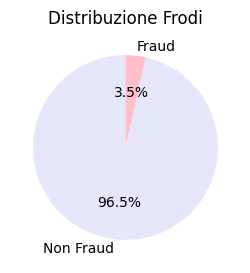

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import duckdb
import re
from scipy import stats



train_transaction=pd.read_csv("train_transaction.csv")
test_transaction=pd.read_csv("test_transaction.csv")

#ESCLUDO V PER MOMENTO
train_transaction = train_transaction.drop(columns=[f"V{i}" for i in range(1,340)])
test_transaction = test_transaction.drop(columns=[f"V{i}" for i in range(1,340)])


#FREQ DI FRAUD
fraud_counts = train_transaction["isFraud"].value_counts()
plt.figure(figsize=(3,3))
plt.pie(
    fraud_counts,
    labels=["Non Fraud", "Fraud"],
    colors=["lavender","Pink"],
    autopct='%1.1f%%',
    startangle=90)

plt.title("Distribuzione Frodi")
plt.show()

## UID CLIENTE

One of the key aspects discussed by several competitors who worked on the IEEE-CIS Fraud Detection dataset is customer identification. Since the dataset does not contain a unique customer ID, a proxy identifier can be created by combining the variables **card1, card2, card3, card5, addr1** (country/region code), and **D1** (days since account opening).

It is important to note that the variable descriptions used in this analysis are not based on official dataset documentation, but rather on insights, discussions, and findings shared by other participants who analyzed the same dataset.

Using this approach, the training set contains approximately **222,452 unique customers**. Among them, **214,253 customers** have only legitimate transactions, **5,093 customers** are always labeled as fraudulent, and only **3,106 customers** have both legitimate and fraudulent transactions over time.

This result highlights an important characteristic of the dataset: customers labeled as fraudulent tend to remain associated with fraudulent activity in future transactions, while changes in behavior (from legitimate to fraudulent or vice versa) are relatively rare. This suggests that customer-level historical information can play a crucial role in improving fraud detection models.

NB: In the test-set we have new clients. (Total unique customers in train: 222,452
Total unique customers in test: 197,974
Customers already seen in train: 26,892
New customers only in test: 171,082

% Known customers in test: 13.58%
% New customers in test: 86.42%)

In [2]:
#DIFF PER TUTTE LE D
d_cols = [f"D{i}" for i in range(1, 16)]
for d in d_cols:
    train_transaction[f"{d}n"] = (np.floor(train_transaction['TransactionDT'] / (24 * 60 * 60)) - train_transaction[d])
    test_transaction[f"{d}n"] = (np.floor(test_transaction['TransactionDT'] / (24 * 60 * 60)) - test_transaction[d])

# Costruzione UID
cols = ['card1', 'card2', 'card3', 'card5', 'addr1', 'D1n']

train_uid = train_transaction[cols].astype(str).agg('_'.join, axis=1)
test_uid  = test_transaction[cols].astype(str).agg('_'.join, axis=1)

all_uid = pd.concat([train_uid, test_uid])

uid_map = {
    uid: i + 1
    for i, uid in enumerate(all_uid.unique())
}

train_transaction["ID_CLIENTE"] = train_uid.map(uid_map)
test_transaction["ID_CLIENTE"]  = test_uid.map(uid_map)

## CALCOLO PERCENTUALI E NUMERICHE SU CLIENTE

In [3]:
train_clients = set(train_transaction["ID_CLIENTE"].unique())
test_clients = set(test_transaction["ID_CLIENTE"].unique())
known_clients = test_clients.intersection(train_clients)


new_clients = test_clients.difference(train_clients)
print(f"Total unique customers in train: {len(train_clients):,}")
print(f"Total unique customers in test: {len(test_clients):,}")
print(f"Customers already seen in train: {len(known_clients):,}")
print(f"New customers only in test: {len(new_clients):,}")
print(f"\n% Known customers in test: {len(known_clients)/len(test_clients)*100:.2f}%")
print(f"% New customers in test: {len(new_clients)/len(test_clients)*100:.2f}%")

Total unique customers in train: 222,452
Total unique customers in test: 197,974
Customers already seen in train: 26,892
New customers only in test: 171,082

% Known customers in test: 13.58%
% New customers in test: 86.42%


In [4]:
# Top 10 clienti con più operazioni fraudolente
top_fraud_clients = (
    train_transaction[train_transaction["isFraud"] == 1]
    .groupby("ID_CLIENTE")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="num_transactions")
)

print("Top 10 customers with most fraudulent transactions:")
display(top_fraud_clients)


# Top 10 clienti con più operazioni non fraudolente
top_legit_clients = (
    train_transaction[train_transaction["isFraud"] == 0]
    .groupby("ID_CLIENTE")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="num_transactions")
)

print("Top 10 customers with most legitimate transactions:")
display(top_legit_clients)

# Numero totale di transazioni per cliente
customer_transactions = (
    train_transaction
    .groupby("ID_CLIENTE")
    .size()
    .reset_index(name="num_transactions")
)


# Creazione delle categorie
customer_transactions["transaction_group"] = pd.cut(
    customer_transactions["num_transactions"],
    bins=[0, 1, 5, 10, 100, np.inf],
    labels=[
        "1 transaction",
        "2-5 transactions",
        "5-10 transactions",
        "10-100 transactions",
        ">100 transactions"
    ]
)


# Tabella riassuntiva
transaction_distribution = (
    customer_transactions["transaction_group"]
    .value_counts()
    .sort_index()
    .reset_index()
)

transaction_distribution.columns = [
    "Transaction range",
    "Number of customers"
]

transaction_distribution["Percentage"] = (
    transaction_distribution["Number of customers"] /
    transaction_distribution["Number of customers"].sum() * 100
).round(2)


display(transaction_distribution)

Top 10 customers with most fraudulent transactions:


,ID_CLIENTE,num_transactions
0,2404,90
1,3103,84
2,164793,80
3,9588,78
4,14084,76
5,39680,75
6,164351,64
7,30048,58
8,12443,55
9,163348,54


Top 10 customers with most legitimate transactions:


,ID_CLIENTE,num_transactions
0,176468,1414
1,198,444
2,7214,231
3,13090,215
4,514,196
5,3401,191
6,1986,174
7,52183,172
8,1404,147
9,2432,142


,Transaction range,Number of customers,Percentage
0,1 transaction,128947,57.97
1,2-5 transactions,71074,31.95
2,5-10 transactions,14348,6.45
3,10-100 transactions,8058,3.62
4,>100 transactions,25,0.01


In [5]:
# import duckdb

# query = """

# SELECT count(distinct id_cliente)
# FROM train_transaction
# where isFraud=0 and id_cliente not in (select distinct id_cliente from train_transaction where isFraud=1)

# """

#222452 clienti tot
#214253 sempre 0
#5093 sempre 1
#3106 sono cambiati

#C D E M (ANCHE V) FARE GROUP BY PER CLIENTE
#IDEA: CREARE UN MODELLO CHE PREVEDE QUELLI = E QUELLI <> . E USARE QUESTA VAR POI PER PREBEDERE FRAUD (IDEA PIU AVANZATA)

query = """

SELECT *
FROM train_transaction
where id_cliente=176468

"""

result = duckdb.query(query).to_df()
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 5)
result

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,D1n,D2n,D3n,D4n,D5n,D6n,D7n,D8n,D9n,D10n,D11n,D12n,D13n,D14n,D15n,ID_CLIENTE
0,3428022,0,11204367,100.0,S,15775,481.0,150.0,mastercard,102.0,credit,330.0,87.0,NaN,8.0,None,yahoo.com,3.0,2.0,0.0,3.0,0.0,0.0,0.0,2.0,0.0,1.0,2.0,0.0,32.0,3.0,0.0,NaN,NaN,NaN,NaN,214.0,56.0,214.666672,0.666666,211.0,NaN,NaN,NaN,214.0,214.0,None,None,None,None,None,None,None,None,None,129.0,NaN,NaN,NaN,NaN,-85.0,73.0,-85.666672,128.333334,-82.0,NaN,NaN,NaN,-85.0,-85.0,176468
1,3455679,0,12081968,10.0,S,15775,481.0,150.0,mastercard,102.0,credit,330.0,87.0,NaN,7.0,None,yahoo.com,3.0,2.0,0.0,3.0,0.0,0.0,0.0,3.0,0.0,1.0,2.0,0.0,33.0,3.0,10.0,10.0,10.0,NaN,NaN,224.0,10.0,NaN,NaN,221.0,NaN,NaN,NaN,224.0,224.0,None,None,None,None,None,None,None,None,None,129.0,129.0,129.0,NaN,NaN,-85.0,129.0,NaN,NaN,-82.0,NaN,NaN,NaN,-85.0,-85.0,176468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1412,3568436,0,15527523,30.0,S,15775,481.0,150.0,mastercard,102.0,credit,330.0,87.0,NaN,7.0,None,yahoo.com,5.0,3.0,0.0,3.0,0.0,0.0,0.0,8.0,0.0,3.0,5.0,0.0,67.0,5.0,50.0,50.0,1.0,NaN,NaN,264.0,1.0,34.708332,0.708333,261.0,NaN,NaN,34.0,264.0,264.0,None,None,None,None,None,None,None,None,None,129.0,129.0,178.0,NaN,NaN,-85.0,178.0,144.291668,178.291667,-82.0,NaN,NaN,145.0,-85.0,-85.0,176468
1413,3573575,0,15701201,120.0,S,15775,481.0,150.0,mastercard,102.0,credit,330.0,87.0,NaN,7.0,None,yahoo.com,5.0,3.0,0.0,3.0,0.0,0.0,0.0,8.0,0.0,3.0,5.0,0.0,68.0,5.0,52.0,52.0,2.0,NaN,NaN,266.0,2.0,36.708332,0.708333,263.0,NaN,NaN,36.0,266.0,266.0,None,None,None,None,None,None,None,None,None,129.0,129.0,179.0,NaN,NaN,-85.0,179.0,144.291668,180.291667,-82.0,NaN,NaN,145.0,-85.0,-85.0,176468


## TransactionDT - Trasformo in date: da 01/01/2025 a 31/07/2025

For simplicity, the **TransactionDT** variable has been converted into a specific datetime range. During the analysis of discussions and solutions shared by other competitors, several references were made to specific time periods and temporal patterns.

However, no official documentation confirming the actual time range of the dataset was found. Therefore, an arbitrary assumption was made by setting the earliest transaction date as **01/01/2025** and assigning the following transactions accordingly based on the original time intervals.

This transformation is only used to facilitate temporal analysis and visualization, while preserving the relative time differences between transactions.

In [6]:
def numero_to_data(numero):
    base = datetime(2025, 1, 1, 0, 0, 0)
    delta_secondi = numero - 86400
    return base + timedelta(seconds=delta_secondi)

train_transaction["TransactionDT"] = train_transaction["TransactionDT"].apply(numero_to_data)
test_transaction["TransactionDT"] = test_transaction["TransactionDT"].apply(numero_to_data)

stats_mese = (train_transaction.groupby(pd.Grouper(key="TransactionDT", freq="M"))["isFraud"].agg(["sum", "count"]))

stats_mese["fraud_rate"] = stats_mese["sum"] / stats_mese["count"]
 
print(stats_mese)

                sum   count  fraud_rate
TransactionDT                          
2025-01-31     3550  137321    0.025852
2025-02-28     3320   83485    0.039768
...             ...     ...         ...
2025-06-30     2995   86572    0.034595
2025-07-31      119    2754    0.043210

[7 rows x 3 columns]


## PRE-PROCESSING

### FUNZIONE - PRIMO PROC

In [7]:
class PreprocessorFit:

    def __init__(self, cat_cols):
        self.cat_cols = cat_cols
        self.ohe = None
        self.ohe_cols = None

    # ==========================================================
    # FIT
    # ==========================================================
    def fit(self, df):
        df = df.copy()

        # ONE HOT
        self.ohe = OneHotEncoder(
            sparse_output=False,
            handle_unknown="ignore"
        )

        self.ohe.fit(df[self.cat_cols])
        self.ohe_cols = self.ohe.get_feature_names_out(self.cat_cols)

        return self

    # ==========================================================
    # TRANSFORM
    # ==========================================================
    def transform(self, df):

        df = df.copy()

        # ------------------------------------------------------
        # 1. EMAIL CLEANING
        # ------------------------------------------------------
        df = self._clean_email(df)

        # ------------------------------------------------------
        # 2. EMAIL FLAG
        # ------------------------------------------------------
        df = self._make_email_flag(df)

        # ------------------------------------------------------
        # 3. ADDRESS FLAG
        # ------------------------------------------------------
        df = self._make_addr_flag(df)

        # ------------------------------------------------------
        # 4. ONE HOT ENCODING
        # ------------------------------------------------------
        ohe_array = self.ohe.transform(df[self.cat_cols])

        ohe_df = pd.DataFrame(
            ohe_array,
            columns=self.ohe_cols,
            index=df.index
        )

        df = df.drop(columns=self.cat_cols)
        df = pd.concat([df, ohe_df], axis=1)

        # ------------------------------------------------------
        # 5. DROP UNUSED
        # ------------------------------------------------------
        df = df.drop(
            columns=["addr1", "addr2"],
            errors="ignore"
        )

        df["dist1"] = df["dist1"].fillna(-1)
        df["dist2"] = df["dist2"].fillna(-1)
        df["is_convertito"] = (df["TransactionAmt"].round(3)!= df["TransactionAmt"].round(2)).astype(int) #MONETA CONVERTITA

        return df

    # ==========================================================
    # HELPERS
    # ==========================================================
    @staticmethod
    def _clean_email(df):

        for col in ["P_emaildomain", "R_emaildomain"]:

            if col in df.columns:

                df[col] = df[col].apply(
                    lambda x:
                    x.split(".")[0]
                    if isinstance(x, str) and "." in x
                    else x
                )

        return df

    @staticmethod
    def _make_email_flag(df):

        p = df["P_emaildomain"]
        r = df["R_emaildomain"]

        conditions = [
            p.isna() & r.isna(),
            p.isna() & r.notna(),
            p.notna() & r.isna(),
            p.notna() & r.notna() & (p != r),
            p.notna() & r.notna() & (p == r),
        ]

        df["email_flag"] = np.select(
            conditions,
            [0, 1, 2, 3, 4],
            default=-1
        )

        df = df.drop(
            columns=["P_emaildomain", "R_emaildomain"],
            errors="ignore"
        )

        return df

    @staticmethod
    def _make_addr_flag(df):
    
        df["address"] = (
            df["addr1"].fillna(-1).astype(str) + "_" +
            df["addr2"].fillna(-1).astype(str)
        )
    
        return df

### CLEAN CARD

In this preprocessing step, the **card variables** were analyzed separately. Missing values were replaced with fixed placeholders: 0 for numerical variables and "None" for categorical ones. This approach was chosen because the absence of information itself may carry useful predictive value, allowing the model to learn whether missing values are associated with fraudulent behavior rather than simply treating them as unknown.

Based on the analysis and discussions within the Kaggle community, the numerical card variables appear to act as customer-specific identifiers. In fact, they are also used as part of the proxy customer ID constructed earlier in the analysis. On the other hand, the categorical card variables seem to describe characteristics of the payment card used for the transaction, although this interpretation is based on community findings rather than official dataset documentation.

In [8]:
def process_cards(df: pd.DataFrame):
    df = df.copy()
    
    card_all = ["card1", "card2", "card3", "card4", "card5", "card6"]
    card_num = ["card2", "card3", "card5"]   # numeriche → 0
    card_cat = ["card4", "card6"]            # categoriche → "None"

    # =========================================================
    # FLAG — count NaN da card1 a card6
    # =========================================================
    df["card_nan_count"] = df[card_all].isna().sum(axis=1)

    # =========================================================
    # FILL
    # =========================================================
    df[card_num] = df[card_num].fillna(0)
    df[card_cat] = df[card_cat].fillna("None")

    return df


train_transaction_i = process_cards(train_transaction)
test_transaction_i = process_cards(test_transaction)


preprocessor = PreprocessorFit(cat_cols=[])

preprocessor.fit(train_transaction_i)

X_train = preprocessor.transform(train_transaction_i)
X_test = preprocessor.transform(test_transaction_i)
print(X_train.isna().sum()[X_train.isna().sum() > 0])

D1        1269
D2      280797
         ...  
D14n    528353
D15n     89113
Length: 39, dtype: int64


In [9]:
query = """

SELECT distinct card4, card6
FROM train_transaction

"""

result = duckdb.query(query).to_df()
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 15)
result

,card4,card6
0,visa,credit
1,mastercard,credit
2,discover,debit
3,None,None
4,None,credit
5,mastercard,debit
6,visa,debit
7,discover,credit
8,None,debit
9,american express,charge card


### C, D E M

In this section, the numerical **C** (from C1 to C15), **D** (from D1 to D16, including their normalized versions), and **M** (from M1 to M9) variables were processed. A consistent preprocessing strategy was applied across these groups. Missing values were replaced with -1 for numerical variables and "None" for categorical ones, treating missing information as a potentially informative feature rather than simply imputing or removing it.

For the C and D variables, additional aggregated features were created by computing **summary statistics** (such as counts, means, standard deviations, minimums, maximums, and other cumulative measures). The goal was to capture the overall information contained in each group of related variables while reducing redundancy and providing the model with more informative features.

Since the M variables are categorical, a different approach was adopted. Instead of calculating numerical statistics, new features were generated by **counting the occurrences of each category** (e.g., the number of T, F, or missing values) for each transaction. This provides a compact representation of the information contained in the entire group of M variables.

In [10]:
def create_c_features(df):
    df = df.copy()
    c_cols = [f"C{i}" for i in range(1, 15)]
    vals = df[c_cols].values  # shape (n_rows, 14)

    df["C_sum"]  = vals.sum(axis=1)
    df["C_mean"] = vals.mean(axis=1)
    df["C_std"]  = vals.std(axis=1)
    df["C_min"]  = vals.min(axis=1)
    df["C_max"]  = vals.max(axis=1)
    df["C_median"] = np.median(vals, axis=1)
    df["C_skew"] = stats.skew(vals, axis=1)
    df["C_kurt"] = stats.kurtosis(vals, axis=1)

    df["C_range"] = df["C_max"] - df["C_min"]
    abs_vals = np.abs(vals)
    df["C_abs_mean"] = abs_vals.mean(axis=1)
    df["C_l1_norm"]  = abs_vals.sum(axis=1)
    df["C_max_abs"]  = abs_vals.max(axis=1)

    df["C_zero_ratio"] = (vals == 0).mean(axis=1)
    df["C_pos_ratio"]  = (vals > 0).mean(axis=1)
    df["C_neg_ratio"]  = (vals < 0).mean(axis=1)
    df["C_pos_sum"] = np.clip(vals, 0, None).sum(axis=1)
    df["C_neg_sum"] = np.clip(vals, None, 0).sum(axis=1)

    df["C_l2_norm"] = np.sqrt((vals ** 2).sum(axis=1))
    df["C_rms"]     = np.sqrt((vals ** 2).mean(axis=1))

    df["C_mean_over_std"] = np.where(df["C_std"] > 1e-6, df["C_mean"] / df["C_std"], 0)
    df["C_max_over_mean"] = df["C_max"] / (df["C_mean"] + 1e-6)

    # quantili vettorizzati
    q_levels = np.arange(0.1, 1.0, 0.1)
    q_vals = np.percentile(vals, q_levels * 100, axis=1)  # shape (9, n_rows)
    for i, q in enumerate(q_levels):
        df[f"C_q{int(round(q*10))}"] = q_vals[i]

    # --- nuove feature ---
    # diversità / conteggi
    df["C_nunique"] = [len(np.unique(row)) for row in vals]
    df["C_nonzero_count"] = (vals != 0).sum(axis=1)

    # dispersione robusta
    q25 = q_vals[1]  # corrisponde a q=0.2... attenzione, serve Q25/Q75 esatti
    q75 = np.percentile(vals, 75, axis=1)
    q25_exact = np.percentile(vals, 25, axis=1)
    df["C_iqr"] = q75 - q25_exact

    # concentrazione
    df["C_top1_ratio"] = np.where(df["C_sum"] != 0, df["C_max"] / df["C_sum"], 0)

    # coefficient of variation
    df["C_cv"] = np.where(df["C_mean"] != 0, df["C_std"] / (df["C_mean"] + 1e-6), 0)

    return df

X_train = create_c_features(X_train)
X_test = create_c_features(X_test)

In [11]:
def create_d_features(df):
    df = df.copy()
    d_cols = [f"D{i}" for i in range(1, 16)] + [f"D{i}n" for i in range(1, 16)]  # sia D che diff

    # conta NaN originali PRIMA di toccare i dati
    df["D_na_count"] = df[d_cols].isna().sum(axis=1)
    df["D_na_ratio"] = df["D_na_count"] / len(d_cols)

    vals = df[d_cols].values  # NaN ancora presenti, non riempiti

    # numpy nanXXX ignora i NaN correttamente (a differenza di fillna(-999))
    df["D_sum"]  = np.nansum(vals, axis=1)
    df["D_mean"] = np.nanmean(vals, axis=1)
    df["D_std"]  = np.nanstd(vals, axis=1)
    df["D_min"]  = np.nanmin(vals, axis=1)
    df["D_max"]  = np.nanmax(vals, axis=1)
    df["D_median"] = np.nanmedian(vals, axis=1)
    df["D_skew"] = stats.skew(vals, axis=1, nan_policy='omit')
    df["D_kurt"] = stats.kurtosis(vals, axis=1, nan_policy='omit')

    df["D_range"] = df["D_max"] - df["D_min"]
    abs_vals = np.abs(vals)
    df["D_abs_mean"] = np.nanmean(abs_vals, axis=1)
    df["D_l1_norm"]  = np.nansum(abs_vals, axis=1)
    df["D_max_abs"]  = np.nanmax(abs_vals, axis=1)

    df["D_zero_ratio"] = np.nanmean(vals == 0, axis=1)
    df["D_pos_ratio"]  = np.nanmean(vals > 0, axis=1)
    df["D_neg_ratio"]  = np.nanmean(vals < 0, axis=1)
    df["D_pos_sum"] = np.nansum(np.clip(vals, 0, None), axis=1)
    df["D_neg_sum"] = np.nansum(np.clip(vals, None, 0), axis=1)

    df["D_l2_norm"] = np.sqrt(np.nansum(vals ** 2, axis=1))
    df["D_rms"]     = np.sqrt(np.nanmean(vals ** 2, axis=1))

    df["D_mean_over_std"] = np.where(df["D_std"] > 1e-6, df["D_mean"] / df["D_std"], 0)
    df["D_max_over_mean"] = df["D_max"] / (df["D_mean"] + 1e-6)

    # quantili vettorizzati, NaN-safe
    q_levels = np.arange(0.1, 1.0, 0.1)
    q_vals = np.nanpercentile(vals, q_levels * 100, axis=1)
    for i, q in enumerate(q_levels):
        df[f"D_q{int(round(q*10))}"] = q_vals[i]

    # --- feature aggiuntive, come per C ---
    df["D_nunique"] = [len(np.unique(row[~np.isnan(row)])) for row in vals]
    df["D_nonzero_count"] = np.nansum(vals != 0, axis=1)

    q75 = np.nanpercentile(vals, 75, axis=1)
    q25 = np.nanpercentile(vals, 25, axis=1)
    df["D_iqr"] = q75 - q25

    df["D_top1_ratio"] = np.where(df["D_sum"] != 0, df["D_max"] / df["D_sum"], 0)
    df["D_cv"] = np.where(df["D_mean"] != 0, df["D_std"] / (df["D_mean"] + 1e-6), 0)

    df[d_cols] = df[d_cols].fillna(-999)

    return df

X_train = create_d_features(X_train)
X_test = create_d_features(X_test)

C:\Users\anton\AppData\Local\Temp\ipykernel_6640\2556098939.py:13: RuntimeWarning: Mean of empty slice
  df["D_mean"] = np.nanmean(vals, axis=1)
c:\users\anton\appdata\local\programs\python\python38\lib\site-packages\numpy\lib\nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\anton\AppData\Local\Temp\ipykernel_6640\2556098939.py:15: RuntimeWarning: All-NaN slice encountered
  df["D_min"]  = np.nanmin(vals, axis=1)
C:\Users\anton\AppData\Local\Temp\ipykernel_6640\2556098939.py:16: RuntimeWarning: All-NaN slice encountered
  df["D_max"]  = np.nanmax(vals, axis=1)
c:\users\anton\appdata\local\programs\python\python38\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
c:\users\anton\appdata\local\programs\python\python38\lib\site-packages\numpy\lib\shape_base.py:402: RuntimeWarning: Prec

In [12]:
def create_m_features(df):

    df = df.copy()

    # =========================================================
    # M1-M9 EXCLUDING M4
    # =========================================================
    m_cols = [f"M{i}" for i in range(1, 10) if f"M{i}" != "M4"]

    df["M_T_count"] = (df[m_cols] == "T").sum(axis=1)

    df["M_F_count"] = (df[m_cols] == "F").sum(axis=1)

    df["M_nan_count"] = df[m_cols].isna().sum(axis=1)
    df["M_nan_ratio"] = df["M_nan_count"] / len(m_cols)


    df["M4_str"] = df["M4"].fillna("None")


    return df
    
X_train = create_m_features(X_train)
X_test = create_m_features(X_test)

In [13]:
def drop_original_columns(df):

    df = df.copy()
    m_cols = [f"M{i}" for i in range(1, 10)]
    cols_to_drop = m_cols
    df = df.drop(columns=cols_to_drop, errors="ignore")

    return df

    
X_train = drop_original_columns(X_train)
X_test = drop_original_columns(X_test)

print(X_train.isna().sum()[X_train.isna().sum() > 0])
print(X_test.isna().sum()[X_test.isna().sum() > 0]) #C ha dei null che non c'erano su Test. Valutare imputazione con media condizionata o altro modo!!
#X_train.to_csv("train_trans_second.csv", index=False)

D_mean      48
D_std       48
D_min       48
D_max       48
D_median    48
            ..
D_q7        48
D_q8        48
D_q9        48
D_iqr       48
D_cv        48
Length: 23, dtype: int64
C1        3
C2        3
C3        3
C4        3
C5        3
         ..
D_q7     65
D_q8     65
D_q9     65
D_iqr    65
D_cv     65
Length: 66, dtype: int64


In [14]:
X_test = X_test.fillna(-1)
print(X_test.isna().sum()[X_test.isna().sum() > 0])

Series([], dtype: int64)


### Variabili categoriche

I'm saving the category columns which I'll encode later.

In [16]:
#colonne fare freq econding e target encoing
CATE = [
    "ProductCD", "card4", "card6", "card1", "card2",
    "card3", "card5", "M4_str", "address"
]

X_train[CATE] = X_train[CATE].astype("string")
X_test[CATE] = X_test[CATE].astype("string")


X_train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,dist1,dist2,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,D1n,D2n,D3n,D4n,D5n,D6n,D7n,D8n,D9n,D10n,D11n,D12n,D13n,D14n,D15n,ID_CLIENTE,card_nan_count,email_flag,address,is_convertito,C_sum,C_mean,C_std,C_min,C_max,C_median,C_skew,C_kurt,C_range,C_abs_mean,C_l1_norm,C_max_abs,C_zero_ratio,C_pos_ratio,C_neg_ratio,C_pos_sum,C_neg_sum,C_l2_norm,C_rms,C_mean_over_std,C_max_over_mean,C_q1,C_q2,C_q3,C_q4,C_q5,C_q6,C_q7,C_q8,C_q9,C_nunique,C_nonzero_count,C_iqr,C_top1_ratio,C_cv,D_na_count,D_na_ratio,D_sum,D_mean,D_std,D_min,D_max,D_median,D_skew,D_kurt,D_range,D_abs_mean,D_l1_norm,D_max_abs,D_zero_ratio,D_pos_ratio,D_neg_ratio,D_pos_sum,D_neg_sum,D_l2_norm,D_rms,D_mean_over_std,D_max_over_mean,D_q1,D_q2,D_q3,D_q4,D_q5,D_q6,D_q7,D_q8,D_q9,D_nunique,D_nonzero_count,D_iqr,D_top1_ratio,D_cv,M_T_count,M_F_count,M_nan_count,M_nan_ratio,M4_str
0,2987000,0,2025-01-01 00:00:00,68.5,W,13926,0.0,150.0,discover,142.0,credit,19.0,-1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,-999.0,13.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,13.0,13.0,-999.0,-999.0,-999.0,0.0,-13.0,-999.0,-12.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-12.0,-12.0,-999.0,-999.0,-999.0,1.0,1,1,0,315.0_87.0,0,8.0,0.571429,0.622700,0.0,2.0,0.5,0.615800,-0.570637,2.0,0.571429,8.0,2.0,0.500000,0.500000,0.0,8.0,0.0,3.162278,0.845154,0.917663,3.499994,0.0,0.0,0.0,0.0,0.5,1.0,1.0,1.0,1.0,3,7,1.00,0.250000,1.089723,20,0.666667,5.0,0.5,11.412712,-13.0,14.0,0.5,0.0,-1.744982,27.0,10.300000,103.0,14.0,0.033333,0.166667,0.133333,54.0,-49.0,36.124784,11.423660,0.043811,27.999944,-12.1,-12.0,-12.0,-4.8,0.5,5.8,13.0,13.0,13.1,6,29,25.0,2.80,22.825379,4,1,3,0.375,M2
1,2987001,0,2025-01-01 00:00:01,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,-1.0,-1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,-999.0,-999.0,0.0,-999.0,-999.0,-999.0,-999.0,-999.0,0.0,-999.0,-999.0,-999.0,-999.0,0.0,1.0,-999.0,-999.0,1.0,-999.0,-999.0,-999.0,-999.0,-999.0,1.0,-999.0,-999.0,-999.0,-999.0,1.0,2,0,2,325.0_87.0,0,6.0,0.428571,0.494872,0.0,1.0,0.0,0.288675,-1.916667,1.0,0.428571,6.0,1.0,0.571429,0.428571,0.0,6.0,0.0,2.449490,0.654654,0.866025,2.333328,0.0,0.0,0.0,0.0,0.0,0.8,1.0,1.0,1.0,2,6,1.00,0.166667,1.154698,22,0.733333,4.0,0.5,0.500000,0.0,1.0,0.5,0.0,-2.000000,1.0,0.500000,4.0,1.0,0.133333,0.133333,0.000000,4.0,0.0,2.000000,0.707107,1.000000,1.999996,0.0,0.0,0.0,0.0,0.5,1.0,1.0,1.0,1.0,2,26,1.0,0.25,0.999998,2,0,6,0.750,M0
2,2987002,0,2025-01-01 00:01:09,59.0,W,4663,490.0,150.0,visa,166.0,debit,287.0,-1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,-999.0,-999.0,0.0,-999.0,-999.0,-999.0,-999.0,-999.0,0.0,315.0,-999.0,-999.0,-999.0,315.0,1.0,-999.0,-999.0,1.0,-999.0,-999.0,-999.0,-999.0,-999.0,1.0,-314.0,-999.0,-999.0,-999.0,-314.0,3,0,2,330.0_87.0,0,7.0,0.500000,0.500000,0.0,1.0,0.5,0.000000,-2.000000,1.0,0.500000,7.0,1.0,0.500000,0.500000,0.0,7.0,0.0,2.645751,0.707107,1.000000,1.999996,0.0,0.0,0.0,0.0,0.5,1.0,1.0,1.0,1.0,2,7,1.00,0.142857,0.999998,20,0.666667,5.0,0.5,198.907642,-314.0,315.0,0.5,0.0,-0.500019,629.0,126.100000,1261.0,315.0,0.100000,0.166667,0.066667,633.0,-628.0,629.003180,198.908270,0.002514,629.998740,-314.0,-62.8,0.0,0.0,0.5,1.0,1.0,63.8,315.0,4,27,1.0,63.00,397.814488,3,5,0,0.000,M0
3,2987003,0,2025-01-01 00:01:39,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,-1.0,-1.0,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,-999.0,-999.0,-999.0,-999.0,84.0,-999.0,-999.0,-999.0,-999.0,111.0,-111.0,-111.0,1.0,-93.0,1.0,-999.0,-999.0,-999.0,-999.0,-83.0,-999.0,-999.0,-999.0,-999.0,-110.0,4,0,2,476.0_87.0,0,39.0,2.785714,6.349112,0.0,25.0,0.5,3.015751,7.725121,25.0,2.785714,39.0,25.0,0.500000,0.500000,0.0,39.0,0.0,25.942244,6.933356,0.438757,8.974356,0.0,0.0,0.0,0.0,0.5,1.0,1.1,2.8,4.7,6,7,1.75,0.641026,2.279168,16,0.533333,7.0,0.5,86.841193,-111.0,112.0,0.5,0.0,-1

### DIGIT FOR TransactionAmt e Card concatenate

I extracted the relevant **digital features** using only the fields contained in **AMT_COLS** and **CARD_COLS**. Specifically, I selected the transaction amount variable (TransactionAmt) as the main numerical feature and the card-related variables (card1, card2, card3, and card5) as identifying attributes. 
The card fields were then concatenated together to create a unique combined card identifier, allowing the different card-related attributes to be analyzed as a single feature rather than as separate variables. 
This approach was used to capture **potential patterns** related to transaction amounts and card information while reducing the dimensionality of the original dataset.

In [17]:
def add_digit_features(
    df,
    cols,
    prefix="Digit_"
):

    df = df.copy()
    new_cols = []

    for col in cols:

        values = df[col].fillna(0)
        abs_int = values.abs().astype(np.int64)
        s = abs_int.astype(str)

        # ── PRIME CIFRE (gestisce numeri di qualsiasi lunghezza) ──────────────
        max_digits = s.str.len().max()
        padded = s.str.zfill(max_digits)  # padding a sinistra con zeri

        for i in range(3):
            name = f"{prefix}{col}_digit_{i+1}"
            df[name] = padded.str[i].astype(int)
            new_cols.append(name)

        # ── ULTIME CIFRE ──────────────────────────────────────────────────────
        df[f"{prefix}{col}_last_digit"]        = abs_int % 10
        df[f"{prefix}{col}_second_last_digit"] = (abs_int // 10) % 10
        df[f"{prefix}{col}_third_last_digit"]  = (abs_int // 100) % 10
        df[f"{prefix}{col}_last2"]             = abs_int % 100 #ultimi due
        df[f"{prefix}{col}_last3"]             = abs_int % 1000 #ultimi tre

        new_cols.extend([
            f"{prefix}{col}_last_digit",
            f"{prefix}{col}_second_last_digit",
            f"{prefix}{col}_third_last_digit",
            f"{prefix}{col}_last2",
            f"{prefix}{col}_last3",
        ])

        # ── NUMERO CIFRE ──────────────────────────────────────────────────────
        name = f"{prefix}{col}_n_digits"
        df[name] = s.str.len()
        new_cols.append(name)

        # ── STATISTICHE CIFRE (vettorizzate) ──────────────────────────────────
        # Espande ogni numero in una matrice di cifre
        digit_matrix = (
            padded.apply(lambda x: pd.array(list(x), dtype=int))
        )
        digit_df = pd.DataFrame(digit_matrix.tolist(), index=df.index)

        df[f"{prefix}{col}_digit_sum"]       = digit_df.sum(axis=1)
        df[f"{prefix}{col}_digit_mean"]      = digit_df.mean(axis=1)
        df[f"{prefix}{col}_digit_max"]       = digit_df.max(axis=1)
        df[f"{prefix}{col}_digit_min"]       = digit_df.min(axis=1)
        df[f"{prefix}{col}_digit_prod"]      = digit_df.prod(axis=1)
        df[f"{prefix}{col}_even_digits"]     = (digit_df % 2 == 0).sum(axis=1)
        df[f"{prefix}{col}_odd_digits"]      = (digit_df % 2 == 1).sum(axis=1) #dispari
        df[f"{prefix}{col}_first_last_diff"] = (
            digit_df.iloc[:, 0] - digit_df.iloc[:, -1]
        ).abs()

        new_cols.extend([
            f"{prefix}{col}_digit_sum",
            f"{prefix}{col}_digit_mean",
            f"{prefix}{col}_digit_max",
            f"{prefix}{col}_digit_min",
            f"{prefix}{col}_digit_prod",
            f"{prefix}{col}_even_digits",
            f"{prefix}{col}_odd_digits",
            f"{prefix}{col}_first_last_diff",
        ])

        # ── MODULAR FEATURES ──────────────────────────────────────────────────
        for mod in [3, 5, 7, 9, 11, 13]:
            name = f"{prefix}{col}_mod{mod}"
            df[name] = abs_int % mod
            new_cols.append(name)

        # ── PARTE DECIMALE ────────────────────────────────────────────────────
        if pd.api.types.is_float_dtype(values):
            name = f"{prefix}{col}_decimal"
            df[name] = (values - np.floor(values)).round(6)
            new_cols.append(name)

    return df, new_cols


AMT_COLS  = ["TransactionAmt"]
CARD_COLS = ["card1", "card2", "card3", "card5"]

# ── card_concat su entrambi i dataset ─────────────────────────────────────────

for df in [X_train, X_test]:
    df["card_concat"] = (
        df[CARD_COLS]
        .apply(pd.to_numeric) 
        .astype(np.int64)  
        .astype(str)
        .agg("".join, axis=1)
        .astype(np.int64)
    )

# ── digit features su train ───────────────────────────────────────────────────
X_train, amt_feats  = add_digit_features(X_train, cols=AMT_COLS)
X_train, card_feats = add_digit_features(X_train, cols=["card_concat"])

#── stesse feature su test (stessi new_cols garantiti) ────────────────────────
X_test, _ = add_digit_features(X_test, cols=AMT_COLS)
X_test, _ = add_digit_features(X_test, cols=["card_concat"])

# ── tutte le nuove feature ────────────────────────────────────────────────────
digit_feats = amt_feats + card_feats
print(f"Feature create: {len(digit_feats)}")
#print(digit_feats)

X_train=X_train.drop(columns="card_concat")
X_test=X_test.drop(columns="card_concat")

Feature create: 47


### FEATURE SELECTION STD + CORR

The feature selection process was implemented to reduce the dataset dimensionality by removing irrelevant, redundant, or low-quality variables. The approach combines three filtering techniques: **Information Value** (IV) analysis, **dominant value filtering**, and **correlation filtering**.

First, non-relevant columns such as identifiers (TransactionID, TransactionDT, ID_CLIENTE) and previously handled categorical variables are excluded. Then, the Information Value (IV) of each feature is calculated using the scorecardpy library to measure its predictive power with respect to the target variable (isFraud).

Afterwards, a dominant value filter removes variables where a single value accounts for more than 98% of the observations, as these features provide limited variability. Finally, a correlation filter is applied to numerical variables: when two features are highly correlated (correlation > 0.98), the variable with the lower IV is removed to reduce redundancy.

The final output is a list of discarded variables and the IV table, allowing the retention of the most informative and non-redundant features while improving model efficiency and reducing the risk of overfitting.

In [18]:
import scorecardpy as sc

def feature_selection_iv(df,target, ignore_cols=None,corr_threshold=0.90, dominant_threshold=0.98):

    if ignore_cols is None:
        ignore_cols = []

    ignore_cols = set(ignore_cols)

    # =====================================================
    # CALCOLO IV
    # =====================================================

    features = [
        c for c in df.columns
        if c != target and c not in ignore_cols
    ]

    bins = sc.woebin(
        df[[target] + features],
        y=target,
        print_step=0
    )

    iv_table = sc.iv(
        df[[target] + features],
        y=target
    )

    iv_dict = (
        iv_table
        .set_index("variable")["info_value"]
        .to_dict()
    )

    # =====================================================
    # DOMINANT VALUE FILTER
    # =====================================================

    dominant_drop = []

    for col in features:

        freq = (
            df[col]
            .value_counts(dropna=False, normalize=True)
            .iloc[0]
        )

        if freq >= dominant_threshold:
            dominant_drop.append(col)

    # =====================================================
    # CORRELATION FILTER
    # =====================================================

    numeric_cols = [
        c for c in features
        if pd.api.types.is_numeric_dtype(df[c])
        and c not in dominant_drop
    ]

    corr_matrix = (
        df[numeric_cols]
        .corr()
        .abs()
    )

    corr_drop = set()

    for i in range(len(corr_matrix.columns)):

        for j in range(i):

            corr_value = corr_matrix.iloc[i, j]

            if corr_value > corr_threshold:

                col1 = corr_matrix.columns[i]
                col2 = corr_matrix.columns[j]

                if col1 in corr_drop or col2 in corr_drop:
                    continue

                iv1 = iv_dict.get(col1, 0)
                iv2 = iv_dict.get(col2, 0)

                if iv1 >= iv2:
                    corr_drop.add(col2)
                else:
                    corr_drop.add(col1)

    # =====================================================
    # DROP FINALE
    # =====================================================

    dropped_cols = sorted(
        set(dominant_drop) | corr_drop
    )


    return dropped_cols, iv_table


drop_cols, iv_table = feature_selection_iv(
    df=X_train,
    target="isFraud",
    ignore_cols=[
        "TransactionID",
        "TransactionDT",
        "ID_CLIENTE"
    ] + CATE,
    corr_threshold=0.98,
    dominant_threshold=0.98
)

print("Dropped:", len(drop_cols))
print(drop_cols)

[INFO] creating woe binning ...


c:\users\anton\appdata\local\programs\python\python38\lib\site-packages\scorecardpy\condition_fun.py:34: UserWarning: There are 4 columns have only one unique values, which are removed from input dataset. 
 (ColumnNames: C_min, C_neg_ratio, C_neg_sum, C_q1)
  warnings.warn("There are {} columns have only one unique values, which are removed from input dataset. \n (ColumnNames: {})".format(len(unique1_cols), ', '.join(unique1_cols)))


Binning on 590540 rows and 170 columns in 00:07:02
Dropped: 58
['C1', 'C10', 'C11', 'C2', 'C3', 'C6', 'C7', 'C8', 'C_abs_mean', 'C_iqr', 'C_l1_norm', 'C_l2_norm', 'C_max', 'C_max_abs', 'C_mean', 'C_median', 'C_min', 'C_neg_ratio', 'C_neg_sum', 'C_pos_ratio', 'C_pos_sum', 'C_q1', 'C_q2', 'C_q3', 'C_q5', 'C_q6', 'C_q7', 'C_q8', 'C_range', 'C_rms', 'C_sum', 'C_top1_ratio', 'C_zero_ratio', 'D13', 'D3n', 'D9', 'D_max', 'D_median', 'D_na_ratio', 'D_q5', 'D_range', 'D_rms', 'D_zero_ratio', 'Digit_TransactionAmt_digit_1', 'Digit_TransactionAmt_digit_2', 'Digit_TransactionAmt_digit_3', 'Digit_TransactionAmt_digit_mean', 'Digit_TransactionAmt_digit_min', 'Digit_TransactionAmt_digit_prod', 'Digit_TransactionAmt_even_digits', 'Digit_TransactionAmt_first_last_diff', 'Digit_TransactionAmt_second_last_digit', 'Digit_TransactionAmt_third_last_digit', 'Digit_card_concat_digit_sum', 'Digit_card_concat_even_digits', 'Digit_card_concat_second_last_digit', 'M_nan_count', 'card_nan_count']


### CAMPI SU DETTAGLIO DATA

The date variable was further transformed to extract more specific temporal information that could be useful for identifying patterns in transaction behavior. From the original timestamp, new features were created by separating the month, day, hour, minute, and second, allowing the model to capture possible time-related effects, such as seasonal trends, daily activity patterns, or specific periods associated with fraudulent transactions.

In addition, cyclic transformations were applied to the month variable using sine and cosine encoding. Since months have a natural circular structure (December is close to January), a simple numerical representation would incorrectly treat them as distant values. The sine and cosine features preserve this cyclic relationship by placing consecutive months close together in the transformed space. This allows the model to better capture seasonal patterns and recurring behaviors over the year.

Overall, these engineered features provide additional temporal information and help the model detect potential fraud patterns linked to specific time periods and seasonal cycles.

In [19]:
X_train=X_train.drop(columns=drop_cols)
X_test=X_test.drop(columns=drop_cols)

dt = pd.to_datetime(X_train["TransactionDT"])

X_train["month"]   = dt.dt.month
X_train["day"]     = dt.dt.day
X_train["hour"]    = dt.dt.hour
X_train["minute"]  = dt.dt.minute
X_train["second"]  = dt.dt.second

X_train["mese_sin"] = np.sin(2 * np.pi * X_train["month"] / 12) #tiene conto di ciclicita 1 vicino a 12
X_train["mese_cos"] = np.cos(2 * np.pi * X_train["month"] / 12)

#########################################################################################################

dt = pd.to_datetime(X_test["TransactionDT"])

X_test["month"]   = dt.dt.month
X_test["day"]     = dt.dt.day
X_test["hour"]    = dt.dt.hour
X_test["minute"]  = dt.dt.minute
X_test["second"]  = dt.dt.second

X_test["mese_sin"] = np.sin(2 * np.pi * X_test["month"] / 12) #tiene conto di ciclicita 1 vicino a 12
X_test["mese_cos"] = np.cos(2 * np.pi * X_test["month"] / 12)


X_train.head() #C, D, lasciati. M trattata.

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,dist1,dist2,C4,C5,C9,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D10,D11,D12,D14,D15,D1n,D2n,D4n,D5n,D6n,D7n,D8n,D9n,D10n,D11n,D12n,D13n,D14n,D15n,ID_CLIENTE,email_flag,address,is_convertito,C_std,C_skew,C_kurt,C_mean_over_std,C_max_over_mean,C_q4,C_q9,C_nunique,C_nonzero_count,C_cv,D_na_count,D_sum,D_mean,D_std,D_min,D_skew,D_kurt,D_abs_mean,D_l1_norm,D_max_abs,D_pos_ratio,D_neg_ratio,D_pos_sum,D_neg_sum,D_l2_norm,D_mean_over_std,D_max_over_mean,D_q1,D_q2,D_q3,D_q4,D_q6,D_q7,D_q8,D_q9,D_nunique,D_nonzero_count,D_iqr,D_top1_ratio,D_cv,M_T_count,M_F_count,M_nan_ratio,M4_str,Digit_TransactionAmt_last_digit,Digit_TransactionAmt_last2,Digit_TransactionAmt_last3,Digit_TransactionAmt_n_digits,Digit_TransactionAmt_digit_sum,Digit_TransactionAmt_digit_max,Digit_TransactionAmt_odd_digits,Digit_TransactionAmt_mod3,Digit_TransactionAmt_mod5,Digit_TransactionAmt_mod7,Digit_TransactionAmt_mod9,Digit_TransactionAmt_mod11,Digit_TransactionAmt_mod13,Digit_TransactionAmt_decimal,Digit_card_concat_digit_1,Digit_card_concat_digit_2,Digit_card_concat_digit_3,Digit_card_concat_last_digit,Digit_card_concat_third_last_digit,Digit_card_concat_last2,Digit_card_concat_last3,Digit_card_concat_n_digits,Digit_card_concat_digit_mean,Digit_card_concat_digit_max,Digit_card_concat_digit_min,Digit_card_concat_digit_prod,Digit_card_concat_odd_digits,Digit_card_concat_first_last_diff,Digit_card_concat_mod3,Digit_card_concat_mod5,Digit_card_concat_mod7,Digit_card_concat_mod9,Digit_card_concat_mod11,Digit_card_concat_mod13,month,day,hour,minute,second,mese_sin,mese_cos
0,2987000,0,2025-01-01 00:00:00,68.5,W,13926,0.0,150.0,discover,142.0,credit,19.0,-1.0,0.0,0.0,1.0,0.0,1.0,1.0,14.0,-999.0,13.0,-999.0,-999.0,-999.0,-999.0,-999.0,13.0,13.0,-999.0,-999.0,0.0,-13.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-12.0,-12.0,-999.0,-999.0,-999.0,1.0,1,0,315.0_87.0,0,0.622700,0.615800,-0.570637,0.917663,3.499994,0.0,1.0,3,7,1.089723,20,5.0,0.5,11.412712,-13.0,0.0,-1.744982,10.300000,103.0,14.0,0.166667,0.133333,54.0,-49.0,36.124784,0.043811,27.999944,-12.1,-12.0,-12.0,-4.8,5.8,13.0,13.0,13.1,6,29,25.0,2.80,22.825379,4,1,0.375,M2,8,68,68,2,14,8,0,2,3,5,5,2,3,0.5,0,0,1,2,1,42,142,12,2.428571,9,0,0,6,2,1,2,1,7,3,9,1,1,0,0,0,0.5,0.866025
1,2987001,0,2025-01-01 00:00:01,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,-1.0,-1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,-999.0,-999.0,0.0,-999.0,-999.0,-999.0,-999.0,0.0,-999.0,-999.0,-999.0,0.0,1.0,-999.0,1.0,-999.0,-999.0,-999.0,-999.0,-999.0,1.0,-999.0,-999.0,-999.0,-999.0,1.0,2,2,325.0_87.0,0,0.494872,0.288675,-1.916667,0.866025,2.333328,0.0,1.0,2,6,1.154698,22,4.0,0.5,0.500000,0.0,0.0,-2.000000,0.500000,4.0,1.0,0.133333,0.000000,4.0,0.0,2.000000,1.000000,1.999996,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,2,26,1.0,0.25,0.999998,2,0,0.750,M0,9,29,29,2,11,9,1,2,4,1,2,7,3,0.0,0,2,7,2,1,2,102,13,2.571429,7,0,0,6,2,0,2,2,0,10,6,1,1,0,0,1,0.5,0.866025
2,2987002,0,2025-01-01 00:01:09,59.0,W,4663,490.0,150.0,visa,166.0,debit,287.0,-1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,-999.0,-999.0,0.0,-999.0,-999.0,-999.0,-999.0,0.0,315.0,-999.0,-999.0,315.0,1.0,-999.0,1.0,-999.0,-999.0,-999.0,-999.0,-999.0,1.0,-314.0,-999.0,-999.0,-999.0,-314.0,3,2,330.0_87.0,0,0.500000,0.000000,-2.000000,1.000000,1.999996,0.0,1.0,2,7,0.999998,20,5.0,0.5,198.907642,-314.0,0.0,-0.500019,126.100000,1261.0,315.0,0.166667,0.066667,633.0,-628.0,629.003180,0.002514,629.998740,-314.0,-62.8,0.0,0.0,1.0,1.0,63.8,315.0,4,27,1.0,63.00,397.814488,3,5,0.000,M0,9,59,59,2,14,9,2,2,4,3,5,4,7,0.0,0,4,6,6,1,66,166,13,3.642857,9,0,0,5,6,0,1,1,6,1,3,1,1,0,1,9,0.5,0.866025
3,2987003,0,2025-01-01 00:01:39,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,-1.0,-1.0,0.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,-999.0,-999.0,-999.0,84.0,-999.0,-999.0,-999.0,111.0,-111.0,-111.0,-93.0,1.0,-999.0,-999.0,-999.0,-999.0,-83.0,-999.0,-999.0,-999.0,-999.0,-110.0,4,2,476.0_87.0,0,6.349112,3.015751,7.725121,0.438757,8.974356,0.0,4.7,

## ALTRE INFO DA TRAIN IDENTITY

Additional feature engineering was applied to the variables from the train_identity dataset, which contains extra transaction-related information linked through the TransactionID key. Since many variables contain missing values, these features provide useful but incomplete information.

The missing values were first handled, then numerical and categorical variables were processed separately. Numerical features were enriched by creating statistical aggregations, while categorical variables were transformed into numerical representations where possible and their cardinality was reduced to limit the number of unique classes.

The goal was to extract additional information from identity features while reducing complexity and making them more suitable for the predictive model.

In [20]:
tr_id=pd.read_csv("train_identity.csv")
te_id=pd.read_csv("test_identity.csv")
te_id.columns = te_id.columns.str.replace("-", "_", regex=False)
tr_id.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,NaN,100.0,NotFound,49.0,-300.0,New,NotFound,166.0,NaN,621.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,52.0,NaN,Found,Found,121.0,NaN,410.0,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,NaN,100.0,NotFound,52.0,NaN,New,NotFound,225.0,NaN,176.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,NaN,-300.0,Found,Found,166.0,15.0,529.0,575.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Mac OS X 10_11_6,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


### COLONNE CON TROPPI NAN

In [21]:
drop_cols = []

for col in tr_id.columns:

    # NaN > 90%
    nan_ratio = tr_id[col].isna().mean()

    # un solo valore unico
    n_unique = tr_id[col].nunique(dropna=False)

    if (nan_ratio > 0.90) or (n_unique == 1):
        drop_cols.append(col)

tr_id = tr_id.drop(columns=drop_cols)
te_id = te_id.drop(columns=drop_cols)

print(f'Colonne droppate: {len(drop_cols)}')
print(drop_cols)

Colonne droppate: 9
['id_07', 'id_08', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27']


In [22]:
def preprocess_and_add_nan_count(df, cols_for_count=None,
                                 categorical_fill="None",
                                 prefix="id"):
    df = df.copy()

    # colonne da usare per il conteggio missing
    if cols_for_count is None:
        cols_for_count = df.columns

    # calcolo missing originale
    df[f"{prefix}_nan_count"] = (
        df[cols_for_count]
        .isna()
        .sum(axis=1)
    )

    df[f"{prefix}_nan_count_ratio"] = df[f"{prefix}_nan_count"] / len(cols_for_count)

    # imputazione solo categoriche
    for col in df.columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(categorical_fill)

    return df

# colonne ID che vuoi aggregare
id_cols = tr_id.columns.tolist()

tr_id = preprocess_and_add_nan_count(
    tr_id,
    cols_for_count=id_cols,
    prefix="id"
)

te_id = preprocess_and_add_nan_count(
    te_id,
    cols_for_count=id_cols,
    prefix="id"
)


### ID NUMERICI

In [23]:
def add_id_aggregates(df, col_id_num):

    df = df.copy()

    # conversione numerica senza imputare
    df_num = (
        df[col_id_num]
        .apply(pd.to_numeric, errors="coerce")
    )

    vals = df_num.values

    # =====================
    # statistiche base
    # =====================

    df["id_sum"] = np.nansum(vals, axis=1)
    df["id_mean"] = np.nanmean(vals, axis=1)
    df["id_std"] = np.nanstd(vals, axis=1)
    df["id_min"] = np.nanmin(vals, axis=1)
    df["id_max"] = np.nanmax(vals, axis=1)

    df["id_median"] = np.nanmedian(vals, axis=1)
    df["id_var"] = np.nanvar(vals, axis=1)

    df["id_skew"] = stats.skew(
        vals,
        axis=1,
        nan_policy="omit"
    )

    df["id_kurt"] = stats.kurtosis(
        vals,
        axis=1,
        nan_policy="omit"
    )


    # =====================
    # range e assoluti
    # =====================

    df["id_range"] = df["id_max"] - df["id_min"]

    abs_vals = np.abs(vals)

    df["id_abs_mean"] = np.nanmean(abs_vals, axis=1)
    df["id_abs_sum"] = np.nansum(abs_vals, axis=1)
    df["id_max_abs"] = np.nanmax(abs_vals, axis=1)


    # =====================
    # struttura valori
    # =====================

    df["id_zero_ratio"] = np.nanmean(vals == 0, axis=1)
    df["id_pos_ratio"] = np.nanmean(vals > 0, axis=1)
    df["id_neg_ratio"] = np.nanmean(vals < 0, axis=1)

    df["id_pos_sum"] = np.nansum(
        np.clip(vals, 0, None),
        axis=1
    )

    df["id_neg_sum"] = np.nansum(
        np.clip(vals, None, 0),
        axis=1
    )


    # =====================
    # norme
    # =====================

    df["id_l1_norm"] = np.nansum(abs_vals, axis=1)

    df["id_l2_norm"] = np.sqrt(
        np.nansum(vals ** 2, axis=1)
    )

    df["id_rms"] = np.sqrt(
        np.nanmean(vals ** 2, axis=1)
    )


    # =====================
    # rapporti
    # =====================

    df["id_mean_over_std"] = np.where(
        df["id_std"] > 1e-6,
        df["id_mean"] / df["id_std"],
        0
    )

    df["id_max_over_mean"] = (
        df["id_max"] /
        (df["id_mean"] + 1e-6)
    )


    # =====================
    # quantili
    # =====================

    q_levels = np.arange(0.1, 1.0, 0.1)

    q_vals = np.nanpercentile(
        vals,
        q_levels * 100,
        axis=1
    )

    for i, q in enumerate(q_levels):
        df[f"id_q{int(round(q*10))}"] = q_vals[i]


    # =====================
    # feature extra
    # =====================

    df["id_nunique"] = [
        len(np.unique(row[~np.isnan(row)]))
        for row in vals
    ]

    df["id_nonzero_count"] = np.nansum(
        vals != 0,
        axis=1
    )


    q75 = np.nanpercentile(vals, 75, axis=1)
    q25 = np.nanpercentile(vals, 25, axis=1)

    df["id_iqr"] = q75 - q25


    df["id_top1_ratio"] = np.where(
        df["id_sum"] != 0,
        df["id_max"] / df["id_sum"],
        0
    )


    df["id_cv"] = np.where(
        df["id_mean"] != 0,
        df["id_std"] / (df["id_mean"] + 1e-6),
        0
    )


    # =====================
    # imputazione finale
    # =====================

    df[col_id_num] = df[col_id_num].fillna(-999)

    return df

    
col_id_num = [
    "id_01","id_02","id_03","id_04","id_05","id_06",
    "id_09","id_10","id_11","id_12","id_13","id_14",
    "id_15","id_16","id_17","id_18","id_19","id_20",
    "id_28","id_29","id_32","id_33","id_34"
]

tr_id = add_id_aggregates(tr_id, col_id_num)
te_id = add_id_aggregates(te_id, col_id_num)

tr_id.isna().sum()[tr_id.isna().sum() > 0]
te_id.isna().sum()[te_id.isna().sum() > 0]

Series([], dtype: int64)

### ENCODING CATEGORICHE ID

In [24]:
def preprocess_ids(df):
    
    mapping = {"Found": 0, "None": 1, "NotFound": 2, "New": 3, 'Unknown':2.5}
    cols_map = ["id_15", "id_28", "id_12", "id_16", "id_29"]
    for col in cols_map:
        df[col] = df[col].map(mapping)

    df["id_34"] = df["id_34"].apply(lambda x: -2 if x == "None" else int(str(x).split(":")[1])).astype("float32")


    cols = ["id_35", "id_36", "id_37", "id_38"] 
    df["count_T"] = (df[cols] == "T").sum(axis=1)
    df["count_F"] = (df[cols] == "F").sum(axis=1)
    df["count_None"] = df[cols].isna().sum(axis=1)

    df=df.drop(columns=cols)


    maing = {"None": 0, "desktop": 1, "mobile": 2}
    df["DeviceType"] = df["DeviceType"].map(maing)

    keywords = ["Android", "iOS", "Linux", "Mac", "Windows"]
    
    def map_id30(value, device):
        for source in [str(value), str(device)]:
            source_lower = source.strip().lower()
            for kw in keywords:
                if kw.lower() in source_lower:
                    return kw
        return "None"
    
    df["id_30"] = df.apply(
        lambda row: map_id30(row["id_30"], row["DeviceInfo"]),
        axis=1
    )
    
    df["id_30"] = df["id_30"].fillna("None")
    
    def map_id33(value):
        if pd.isna(value) or str(value).strip().lower() == "none" or str(value).strip() == "0x0":
            return 0
        try:
            parts = str(value).strip().split("x")
            w, h = int(parts[0]), int(parts[1])
            return np.log(w * h)
        except:
            return 0
    
    df["id_33"] = df["id_33"].apply(map_id33)

    
    return df


tr_id=preprocess_ids(tr_id)
te_id=preprocess_ids(te_id)

In [25]:
def parse_browser(df, col):

    df = df.copy()
    s = df[col].fillna("None").astype(str).str.lower().str.strip()

    # ── FAMIGLIA ──────────────────────────────────────────────────────────────
    def get_family(x):
        if 'chrome'   in x: return 'chrome'
        if 'firefox'  in x: return 'firefox'
        if 'safari'   in x: return 'safari'
        if 'samsung'  in x: return 'samsung'
        if 'edge'     in x: return 'edge'
        if 'opera'    in x: return 'opera'
        if 'ie'       in x: return 'ie'
        if 'android'  in x: return 'android'
        if 'mobile'   in x: return 'mobile'
        return 'other'

    # ── DISPOSITIVO ───────────────────────────────────────────────────────────
    def get_device(x):
        if 'android' in x: return 'android'
        if 'ios'     in x: return 'ios'
        if 'mobile'  in x: return 'mobile'
        if 'tablet'  in x: return 'tablet'
        if 'desktop' in x: return 'desktop'
        return 'unknown'

    # ── VERSIONE (major * 100 + minor) ────────────────────────────────────────
    def get_version(x):
        m = re.search(r'(\d+)\.(\d+)', x)
        if m:
            return int(m.group(1)) * 100 + int(m.group(2))
        return -1

    df[f"{col}_family"]       = s.apply(get_family)
    df[f"{col}_device"]       = s.apply(get_device)
    df[f"{col}_version_int"]  = s.apply(get_version)

    # ── BINARIE ───────────────────────────────────────────────────────────────
    df[f"{col}_is_mobile"]    = s.str.contains('android|mobile|ios', na=False).astype(int)
    df[f"{col}_has_version"]  = (df[f"{col}_version_int"] != -1).astype(int)
    df[f"{col}_is_none"]      = (s == 'none').astype(int)

    return df


tr_id = parse_browser(tr_id, col="id_31")
te_id = parse_browser(te_id, col="id_31")

tr_id = tr_id.drop(columns="id_31")
te_id = te_id.drop(columns="id_31")

tr_id = tr_id.drop(columns="DeviceInfo")
te_id = te_id.drop(columns="DeviceInfo")
tr_id.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_28,id_29,id_30,id_32,id_33,id_34,DeviceType,id_nan_count,id_nan_count_ratio,id_sum,id_mean,id_std,id_min,id_max,id_median,id_var,id_skew,id_kurt,id_range,id_abs_mean,id_abs_sum,id_max_abs,id_zero_ratio,id_pos_ratio,id_neg_ratio,id_pos_sum,id_neg_sum,id_l1_norm,id_l2_norm,id_rms,id_mean_over_std,id_max_over_mean,id_q1,id_q2,id_q3,id_q4,id_q5,id_q6,id_q7,id_q8,id_q9,id_nunique,id_nonzero_count,id_iqr,id_top1_ratio,id_cv,count_T,count_F,count_None,id_31_family,id_31_device,id_31_version_int,id_31_is_mobile,id_31_has_version,id_31_is_none
0,2987004,0.0,70787.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,100.0,2.0,-999.0,-480.0,3.0,2.0,166.0,-999.0,542.0,144.0,3.0,2.0,Android,32.0,14.689979,2.0,2,8,0.25000,71291.0,8911.375000,23388.250292,-480.0,70787.0,122.0,5.470103e+08,2.267219,3.141429,71267.0,9031.375000,72251.0,70787.0,0.043478,0.260870,0.043478,71771.0,-480.0,72251.0,70791.121258,25028.440945,0.381019,7.943443,-144.0,12.8,3.880000e+01,86.4,122.0,148.4,163.8,391.6,21615.5,8,22,236.0,0.992930,2.624539,3,1,0,samsung,unknown,602,0,1,0
1,2987008,-5.0,98945.0,-999.0,-999.0,0.0,-5.0,-999.0,-999.0,100.0,2.0,49.0,-300.0,3.0,2.0,166.0,-999.0,621.0,500.0,3.0,2.0,iOS,32.0,13.816010,1.0,2,5,0.15625,100103.0,9100.272727,28412.409415,-300.0,98945.0,49.0,8.072650e+08,2.845679,6.098746,99245.0,9156.636364,100723.0,98945.0,0.043478,0.304348,0.130435,100413.0,-310.0,100723.0,98948.874157,29834.208092,0.320292,10.872751,-5.0,-5.0,1.421085e-14,32.0,49.0,100.0,166.0,500.0,621.0,10,22,335.5,0.988432,3.122149,2,2,0,safari,mobile,1100,1,1,0
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,2.0,52.0,-999.0,0.0,0.0,121.0,-999.0,410.0,142.0,0.0,0.0,Windows,-999.0,0.000000,-2.0,1,6,0.18750,192451.0,14803.923077,51045.700486,-5.0,191631.0,0.0,2.605664e+09,3.175400,8.083231,191636.0,14804.692308,192461.0,191631.0,0.260870,0.260870,0.043478,192456.0,-5.0,192461.0,191631.562627,53149.032696,0.290013,12.944609,0.0,0.0,0.000000e+00,0.0,0.0,61.6,108.4,133.6,356.4,8,17,121.0,0.995739,3.448120,2,2,0,chrome,unknown,6200,0,1,0
3,2987011,-5.0,221832.0,-999.0,-999.0,0.0,-6.0,-999.0,-999.0,100.0,2.0,52.0,-999.0,3.0,2.0,225.0,-999.0,176.0,507.0,3.0,2.0,None,-999.0,0.000000,-2.0,1,11,0.34375,222881.0,24764.555556,69674.033687,-6.0,221832.0,100.0,4.854471e+09,2.474850,4.124934,221838.0,24767.000000,222903.0,221832.0,0.043478,0.260870,0.086957,222892.0,-11.0,222903.0,221832.792073,73944.264024,0.355435,8.957641,-5.2,-2.0,2.080000e+01,61.6,100.0,160.8,205.4,337.8,44772.0,9,22,225.0,0.995293,2.813458,2,2,0,chrome,unknown,6200,0,1,0
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,0.0,0.0,100.0,2.0,-999.0,-300.0,0.0,0.0,166.0,15.0,529.0,575.0,0.0,0.0,Mac,24.0,13.839227,2.0,1,1,0.03125,8570.0,571.333333,1852.819425,-300.0,7460.0,1.0,3.432940e+06,3.400292,9.747421,7760.0,611.333333,9170.0,7460.0,0.260870,0.347826,0.043478,8870.0,-300.0,9170.0,7509.355765,1938.907321,0.308359,13.057176,0.0,0.0,0.000000e+00,0.0,1.0,18.6,84.8,238.6,556.6,10,17,133.0,0.870478,3.242974,3,1,0,chrome,unknown,6200,0,1,0


### Variabili categoriche ID

In [26]:
CATE_ID=["id_30","DeviceType","id_31_family","id_31_device"]

tr_id[CATE_ID] = tr_id[CATE_ID].astype("string")
te_id[CATE_ID] = te_id[CATE_ID].astype("string")

### SELECTION FOR ID VAR

In [27]:
new_train = tr_id.copy()

# ── CORRELAZIONE ────────────────────────────────────────

corr_matrix = new_train.corr(numeric_only=True).abs()

high_corr = []
corr_drop_cols = set()

for i in range(len(corr_matrix.columns)):

    for j in range(i):

        corr_value = corr_matrix.iloc[i, j]

        if corr_value > 0.98:

            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]

            high_corr.append(
                (col1, col2, corr_value)
            )

            # droppa il primo a caso
            corr_drop_cols.add(col1)

print('\n=== HIGH CORRELATION (>0.90) ===')

for c1, c2, corr in high_corr:
    print(f'{c1}  <->  {c2}  =  {corr:.4f}')


# ── LOW STD ─────────────────────────────────────────────

low_std_cols = []

for col in new_train.select_dtypes(include=np.number).columns:

    std_value = new_train[col].std()

    if std_value < 0.001:

        low_std_cols.append(
            (col, std_value)
        )

print('\n=== LOW STD (<0.001) ===')

for col, std_value in low_std_cols:
    print(f'{col}  =  {std_value:.8f}')


# ── COLONNE FINALI DA DROPPARE ──────────────────────────

low_std_drop_cols = [
    col for col, _ in low_std_cols
]

drop_cols = sorted(
    list(
        set(corr_drop_cols | set(low_std_drop_cols))
    )
)

print('\n=== FINAL DROP COLS ===')
print(drop_cols)
print(f'\nTotale colonne da droppare: {len(drop_cols)}')


=== HIGH CORRELATION (>0.90) ===
id_04  <->  id_03  =  1.0000
id_06  <->  id_05  =  0.9965
id_10  <->  id_09  =  1.0000
id_29  <->  id_09  =  0.9889
id_29  <->  id_10  =  0.9889
id_29  <->  id_28  =  0.9804
id_nan_count_ratio  <->  id_nan_count  =  1.0000
id_sum  <->  id_02  =  1.0000
id_std  <->  id_02  =  0.9912
id_std  <->  id_sum  =  0.9912
id_std  <->  id_mean  =  0.9877
id_max  <->  id_02  =  1.0000
id_max  <->  id_sum  =  1.0000
id_max  <->  id_std  =  0.9912
id_range  <->  id_02  =  1.0000
id_range  <->  id_sum  =  1.0000
id_range  <->  id_std  =  0.9912
id_range  <->  id_max  =  1.0000
id_abs_mean  <->  id_mean  =  1.0000
id_abs_mean  <->  id_std  =  0.9877
id_abs_sum  <->  id_02  =  1.0000
id_abs_sum  <->  id_sum  =  1.0000
id_abs_sum  <->  id_std  =  0.9912
id_abs_sum  <->  id_max  =  1.0000
id_abs_sum  <->  id_range  =  1.0000
id_max_abs  <->  id_02  =  1.0000
id_max_abs  <->  id_sum  =  1.0000
id_max_abs  <->  id_std  =  0.9912
id_max_abs  <->  id_max  =  1.0000
id_max_ab

In [28]:
new_train=new_train.drop(columns=drop_cols)
te_id=te_id.drop(columns=drop_cols)

### ADD INFO ID IN JOIN

In [29]:
pd.set_option('display.max_columns', None)

# =========================================================
# LEFT JOIN
# =========================================================
X_training = X_train.merge(
    new_train,
    on="TransactionID",
    how="left"
)

X_testing = X_test.merge(
    te_id,
    on="TransactionID",
    how="left"
)

# =========================================================
# FILL MISSING
# =========================================================
num_cols = X_training.select_dtypes(include=np.number).columns
cat_cols = X_training.select_dtypes(exclude=np.number).columns
X_training[num_cols] = X_training[num_cols].fillna(-9999)
X_training[cat_cols] = X_training[cat_cols].fillna("NoJoin")

print(X_training.shape)

# =========================================================
# FILL MISSING
# =========================================================
num_cols = X_testing.select_dtypes(include=np.number).columns
cat_cols = X_testing.select_dtypes(exclude=np.number).columns
X_testing[num_cols] = X_testing[num_cols].fillna(-9999)
X_testing[cat_cols] = X_testing[cat_cols].fillna("NoJoin")

print(X_testing.shape)

(590540, 185)
(506691, 184)


In [30]:
print(X_training.isna().sum()[X_training.isna().sum() > 0])
print(X_testing.isna().sum()[X_testing.isna().sum() > 0])

Series([], dtype: int64)
Series([], dtype: int64)


In [32]:
X_training.to_csv("train_4.csv", index=False)
X_testing.to_csv("test_4.csv", index=False)

   TransactionID  isFraud       TransactionDT  TransactionAmt ProductCD  \
0        2987000        0 2025-01-01 00:00:00            68.5         W   
1        2987001        0 2025-01-01 00:00:01            29.0         W   
2        2987002        0 2025-01-01 00:01:09            59.0         W   
3        2987003        0 2025-01-01 00:01:39            50.0         W   
4        2987004        0 2025-01-01 00:01:46            50.0         H   

   card1  card2  card3       card4  card5   card6  dist1  dist2   C4   C5  \
0  13926    0.0  150.0    discover  142.0  credit   19.0   -1.0  0.0  0.0   
1   2755  404.0  150.0  mastercard  102.0  credit   -1.0   -1.0  0.0  0.0   
2   4663  490.0  150.0        visa  166.0   debit  287.0   -1.0  0.0  0.0   
3  18132  567.0  150.0  mastercard  117.0   debit   -1.0   -1.0  0.0  0.0   
4   4497  514.0  150.0  mastercard  102.0  credit   -1.0   -1.0  0.0  0.0   

    C9  C12   C13  C14     D1     D2     D3     D4     D5     D6     D7  \
0  1.0  0.0

## Variabili V

Similarly to the C and D variables, the **300 V** variables were processed by creating a set of **aggregated statistics** aimed at extracting as much information as possible from this large group of features. Missing values were replaced with -1, while their occurrences were also counted, following the same assumption adopted throughout the preprocessing stage: missing values may themselves contain useful predictive information rather than simply representing unavailable data.

Given the high dimensionality of the V variables, an additional **feature selection** step was performed to reduce redundancy and retain only the most informative features. Variables that were nearly constant, highly correlated with others, or characterized by a low Information Value (IV) were removed. Finally, the selected V features were merged back into the main dataset, resulting in a more compact and informative feature set for model training.

In [33]:
v_cols = [f"V{i}" for i in range(1, 340)]

train_transaction=pd.read_csv("train_transaction.csv")
test_transaction=pd.read_csv("test_transaction.csv")

train_transaction_v = train_transaction[v_cols + ["isFraud", "TransactionID"]].copy()
test_transaction_v = test_transaction[v_cols + ["TransactionID"]].copy()


def build_v_features(df, v_cols):

    df_out = df.copy()

    # =====================
    # NaN originali
    # =====================

    df_out["V_na_count"] = df_out[v_cols].isna().sum(axis=1)
    df_out["V_na_ratio"] = df_out["V_na_count"] / len(v_cols)

    # valori ancora con NaN
    vals = df_out[v_cols].to_numpy(dtype=np.float32)

    features = pd.DataFrame(index=df_out.index)


    # =====================
    # statistiche base
    # =====================

    features["V_sum"] = np.nansum(vals, axis=1)
    features["V_mean"] = np.nanmean(vals, axis=1)
    features["V_std"] = np.nanstd(vals, axis=1)
    features["V_min"] = np.nanmin(vals, axis=1)
    features["V_max"] = np.nanmax(vals, axis=1)

    features["V_median"] = np.nanmedian(vals, axis=1)
    features["V_var"] = np.nanvar(vals, axis=1)
    features["V_skew"] = stats.skew(vals, axis=1, nan_policy="omit")
    features["V_kurt"] = stats.kurtosis(vals, axis=1, nan_policy="omit")

    # =====================
    # range e assoluti
    # =====================

    features["V_range"] = (features["V_max"] - features["V_min"])

    abs_v = np.abs(vals)

    features["V_abs_mean"] = np.nanmean(abs_v, axis=1)
    features["V_abs_sum"] = np.nansum(abs_v, axis=1)
    features["V_max_abs"] = np.nanmax(abs_v, axis=1)


    # =====================
    # struttura valori
    # =====================

    features["V_zero_ratio"] = np.nanmean(vals == 0, axis=1)
    features["V_pos_ratio"] = np.nanmean(vals > 0, axis=1)
    features["V_neg_ratio"] = np.nanmean(vals < 0, axis=1)

    features["V_pos_sum"] = np.nansum(np.clip(vals, 0, None), axis=1)
    features["V_neg_sum"] = np.nansum(np.clip(vals, None, 0), axis=1)

    # =====================
    # norme
    # =====================

    features["V_l1_norm"] = np.nansum(abs_v, axis=1)
    features["V_l2_norm"] = np.sqrt(np.nansum(vals ** 2, axis=1))
    features["V_rms"] = np.sqrt(np.nanmean(vals ** 2, axis=1))

    # =====================
    # rapporti
    # =====================

    features["V_mean_over_std"] = np.where(features["V_std"] > 1e-6, features["V_mean"] / features["V_std"], 0)
    features["V_max_over_mean"] = (features["V_max"] / (features["V_mean"] + 1e-6))

    # =====================
    # quantili
    # =====================

    q_levels = np.arange(0.1, 1.0, 0.1)

    q_vals = np.nanpercentile(vals, q_levels * 100, axis=1)
    
    for i, q in enumerate(q_levels):
        features[f"V_q{int(round(q*10))}"] = q_vals[i]

    # =====================
    # feature extra
    # =====================

    features["V_nunique"] = [len(np.unique(row[~np.isnan(row)])) for row in vals]
    features["V_nonzero_count"] = np.nansum(vals != 0, axis=1)

    q75 = np.nanpercentile(vals, 75, axis=1)
    q25 = np.nanpercentile(vals, 25, axis=1)

    features["V_iqr"] = q75 - q25
    features["V_top1_ratio"] = np.where(features["V_sum"] != 0, features["V_max"] / features["V_sum"], 0)
    features["V_cv"] = np.where(features["V_mean"] != 0, features["V_std"] / (features["V_mean"] + 1e-6), 0)

    # unione feature
    df_out = pd.concat([df_out, features], axis=1)

    # =====================
    # imputazione finale
    # =====================

    df_out[v_cols] = df_out[v_cols].fillna(-999)

    return df_out
 
train_transaction_v = build_v_features(train_transaction_v, v_cols)
test_transaction_v = build_v_features(test_transaction_v, v_cols)

In [34]:
pd.set_option('display.max_row', None)
train_transaction_v.isna().sum()[train_transaction_v.isna().sum() > 0]/590540
test_transaction_v.isna().sum()[test_transaction_v.isna().sum() > 0]/590540

Series([], dtype: float64)

### SELECTION VAR V

In [35]:
import scorecardpy as sc

def feature_selection_iv(df,target, ignore_cols=None,corr_threshold=0.90, dominant_threshold=0.98):

    if ignore_cols is None:
        ignore_cols = []

    ignore_cols = set(ignore_cols)

    # =====================================================
    # CALCOLO IV
    # =====================================================

    features = [
        c for c in df.columns
        if c != target and c not in ignore_cols
    ]

    bins = sc.woebin(
        df[[target] + features],
        y=target,
        print_step=0
    )

    iv_table = sc.iv(
        df[[target] + features],
        y=target
    )

    iv_dict = (
        iv_table
        .set_index("variable")["info_value"]
        .to_dict()
    )

    # =====================================================
    # DOMINANT VALUE FILTER
    # =====================================================

    dominant_drop = []

    for col in features:

        freq = (
            df[col]
            .value_counts(dropna=False, normalize=True)
            .iloc[0]
        )

        if freq >= dominant_threshold:
            dominant_drop.append(col)

    # =====================================================
    # CORRELATION FILTER
    # =====================================================

    numeric_cols = [
        c for c in features
        if pd.api.types.is_numeric_dtype(df[c])
        and c not in dominant_drop
    ]

    corr_matrix = (
        df[numeric_cols]
        .corr()
        .abs()
    )

    corr_drop = set()

    for i in range(len(corr_matrix.columns)):

        for j in range(i):

            corr_value = corr_matrix.iloc[i, j]

            if corr_value > corr_threshold:

                col1 = corr_matrix.columns[i]
                col2 = corr_matrix.columns[j]

                if col1 in corr_drop or col2 in corr_drop:
                    continue

                iv1 = iv_dict.get(col1, 0)
                iv2 = iv_dict.get(col2, 0)

                if iv1 >= iv2:
                    corr_drop.add(col2)
                else:
                    corr_drop.add(col1)

    # =====================================================
    # DROP FINALE
    # =====================================================

    dropped_cols = sorted(
        set(dominant_drop) | corr_drop
    )


    return dropped_cols, iv_table


In [36]:
drop_cols, iv_table = feature_selection_iv(
    df=train_transaction_v,
    target="isFraud",
    ignore_cols=[
        "TransactionID",
        "TransactionDT",
        "ID_CLIENTE"
    ],
    corr_threshold=0.98,
    dominant_threshold=0.98
)

print("Dropped:", len(drop_cols))
print(drop_cols)


train_transaction_v = train_transaction_v.drop(columns=drop_cols)
test_transaction_v = test_transaction_v.drop(columns=drop_cols)

[INFO] creating woe binning ...


c:\users\anton\appdata\local\programs\python\python38\lib\site-packages\scorecardpy\condition_fun.py:34: UserWarning: There are 2 columns have only one unique values, which are removed from input dataset. 
 (ColumnNames: V_neg_ratio, V_neg_sum)
  warnings.warn("There are {} columns have only one unique values, which are removed from input dataset. \n (ColumnNames: {})".format(len(unique1_cols), ', '.join(unique1_cols)))


Binning on 590540 rows and 377 columns in 00:33:11
Dropped: 286
['V1', 'V100', 'V103', 'V104', 'V105', 'V106', 'V107', 'V108', 'V109', 'V11', 'V110', 'V111', 'V112', 'V113', 'V114', 'V115', 'V116', 'V117', 'V118', 'V119', 'V12', 'V120', 'V121', 'V122', 'V124', 'V125', 'V126', 'V128', 'V13', 'V132', 'V133', 'V134', 'V138', 'V139', 'V14', 'V140', 'V141', 'V142', 'V143', 'V144', 'V145', 'V146', 'V147', 'V148', 'V15', 'V151', 'V152', 'V153', 'V154', 'V155', 'V156', 'V157', 'V158', 'V16', 'V160', 'V161', 'V162', 'V163', 'V167', 'V168', 'V169', 'V17', 'V170', 'V171', 'V172', 'V173', 'V174', 'V175', 'V176', 'V177', 'V178', 'V179', 'V18', 'V180', 'V181', 'V182', 'V183', 'V184', 'V185', 'V186', 'V187', 'V188', 'V189', 'V19', 'V190', 'V191', 'V192', 'V193', 'V194', 'V195', 'V196', 'V197', 'V198', 'V199', 'V2', 'V20', 'V200', 'V206', 'V208', 'V21', 'V210', 'V211', 'V212', 'V217', 'V218', 'V219', 'V22', 'V220', 'V221', 'V222', 'V223', 'V224', 'V225', 'V226', 'V227', 'V228', 'V229', 'V23', 'V230', 

In [38]:
train_transaction_v.head()

,V10,V34,V45,V74,V94,V101,V102,V123,V127,V129,V130,V131,V135,V136,V137,V149,V150,V159,V164,V165,V166,V201,V202,V203,V204,V205,V207,V209,V213,V214,V215,V216,V258,V263,V264,V265,V266,V267,V268,V273,V274,V275,V277,V283,V285,V287,V291,V292,V293,V294,V295,V298,V299,V303,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V319,V320,V321,V333,V335,V337,V338,V339,isFraud,TransactionID,V_na_count,V_var,V_skew,V_kurt,V_range,V_pos_ratio,V_l1_norm,V_mean_over_std,V_max_over_mean,V_q4,V_q5,V_q6,V_q7,V_q8,V_q9,V_nunique,V_nonzero_count,V_iqr,V_top1_ratio,V_cv
0,0.0,0.0,-999.0,0.0,0.0,0.0,1.0,1.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,-999.0,-999.0,-999.000000,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-999.0,-999.0,-999.0,-999.0,-999.0,0,2987000,177,3.276793e+02,6.118943,35.470767,117.000000,0.194690,530.00000,0.180733,35.762253,0.0,0.0,1.0,1.0,1.0,1.0,3,243,1.0,0.220755,5.533036
1,-999.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-999.0,-999.0,-999.000000,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-999.0,-999.0,-999.0,-999.0,-999.0,0,2987001,170,2.152584e-01,0.803477,-1.354425,1.000000,0.156342,53.00000,0.675942,3.188669,0.0,0.0,0.0,1.0,1.0,1.0,2,223,1.0,0.018868,1.479413
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-999.0,-999.0,-999.000000,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-999.0,-999.0,-999.0,-999.0,-999.0,0,2987002,159,2.376539e-01,0.455842,-1.792208,1.000000,0.206490,70.00000,0.797725,2.571422,0.0,0.0,0.0,1.0,1.0,1.0,2,229,1.0,0.014286,1.253562
3,-999.0,0.0,1.0,0.0,0.0,1.0,38.0,1.0,1758.0,0.0,354.0,135.0,0.0,0.0,0.0,-999.0,-999.0,-999.000000,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,0.0,10.0,4.0,1.0,1.0,1.0,38.0,24.0,0.0,0.0,0.0,50.0,1758.0,925.0,0.0,354.0,0.0,135.0,0.0,0.0,0.0,0.0,0.0,0.0,-999.0,-999.0,-999.0,-999.0,-999.0,0,2987003,170,7.478859e+04,4.770921,22.832714,1758.000000,0.265487,11251.00000,0.243437,26.406719,0.0,1.0,1.0,1.0,1.0,40.0,15,260,1.0,0.156253,4.107837
4,-999.0,-999.0,-999.0,-999.0,-999.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1803.0,15557.990234,515.0,5155.0,2840.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,2987004,94,1.180344e+08,15.343568,235.378332,169690.796875,0.253687,195913.78125,0.073603,212.206848,0.0,0.0,0.0,1.0,1.0,1.0,13,180,1.0,0.866150,13.586433


### UNISCO TUTTO

In [43]:
train_tot=pd.read_csv("train_3.csv")
test_tot=pd.read_csv("test_3.csv")
print(train_tot.columns)

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'id_nunique', 'id_top1_ratio', 'count_T', 'count_F', 'id_31_family',
       'id_31_device', 'id_31_version_int', 'id_31_is_mobile',
       'id_31_has_version', 'id_31_is_none'],
      dtype='object', length=185)


In [44]:
cols_to_drop = ["isFraud"]
train_transaction_v_clean = train_transaction_v.drop(columns=cols_to_drop)

train_tot = train_tot.merge(train_transaction_v_clean, on="TransactionID", how="left")
test_tot = test_tot.merge(test_transaction_v, on="TransactionID", how="left")

train_tot.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,dist1,dist2,C4,C5,C9,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D10,D11,D12,D14,D15,D1n,D2n,D4n,D5n,D6n,D7n,D8n,D9n,D10n,D11n,D12n,D13n,D14n,D15n,ID_CLIENTE,email_flag,address,is_convertito,C_std,C_skew,C_kurt,C_mean_over_std,C_max_over_mean,C_q4,C_q9,C_nunique,C_nonzero_count,C_cv,D_na_count,D_sum,D_mean,D_std,D_min,D_skew,D_kurt,D_abs_mean,D_l1_norm,D_max_abs,D_pos_ratio,D_neg_ratio,D_pos_sum,D_neg_sum,D_l2_norm,D_mean_over_std,D_max_over_mean,D_q1,D_q2,D_q3,D_q4,D_q6,D_q7,D_q8,D_q9,D_nunique,D_nonzero_count,D_iqr,D_top1_ratio,D_cv,M_T_count,M_F_count,M_nan_ratio,M4_str,Digit_TransactionAmt_last_digit,Digit_TransactionAmt_last2,Digit_TransactionAmt_last3,Digit_TransactionAmt_n_digits,Digit_TransactionAmt_digit_sum,Digit_TransactionAmt_digit_max,Digit_TransactionAmt_odd_digits,Digit_TransactionAmt_mod3,Digit_TransactionAmt_mod5,Digit_TransactionAmt_mod7,Digit_TransactionAmt_mod9,Digit_TransactionAmt_mod11,Digit_TransactionAmt_mod13,Digit_TransactionAmt_decimal,Digit_card_concat_digit_1,Digit_card_concat_digit_2,Digit_card_concat_digit_3,Digit_card_concat_last_digit,Digit_card_concat_third_last_digit,Digit_card_concat_last2,Digit_card_concat_last3,Digit_card_concat_n_digits,Digit_card_concat_digit_mean,Digit_card_concat_digit_max,Digit_card_concat_digit_min,Digit_card_concat_digit_prod,Digit_card_concat_odd_digits,Digit_card_concat_first_last_diff,Digit_card_concat_mod3,Digit_card_concat_mod5,Digit_card_concat_mod7,Digit_card_concat_mod9,Digit_card_concat_mod11,Digit_card_concat_mod13,month,day,hour,minute,second,mese_sin,mese_cos,id_01,id_02,id_03,id_05,id_09,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_28,id_30,id_32,id_33,id_34,DeviceType,id_nan_count,id_mean,id_min,id_median,id_var,id_skew,id_kurt,id_zero_ratio,id_pos_ratio,id_neg_ratio,id_mean_over_std,id_max_over_mean,id_q1,id_q2,id_q3,id_q4,id_q6,id_q7,id_q9,id_nunique,id_top1_ratio,count_T,count_F,id_31_family,id_31_device,id_31_version_int,id_31_is_mobile,id_31_has_version,id_31_is_none,V10,V34,V45,V74,V94,V101,V102,V123,V127,V129,V130,V131,V135,V136,V137,V149,V150,V159,V164,V165,V166,V201,V202,V203,V204,V205,V207,V209,V213,V214,V215,V216,V258,V263,V264,V265,V266,V267,V268,V273,V274,V275,V277,V283,V285,V287,V291,V292,V293,V294,V295,V298,V299,V303,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V319,V320,V321,V333,V335,V337,V338,V339,V_na_count,V_var,V_skew,V_kurt,V_range,V_pos_ratio,V_l1_norm,V_mean_over_std,V_max_over_mean,V_q4,V_q5,V_q6,V_q7,V_q8,V_q9,V_nunique,V_nonzero_count,V_iqr,V_top1_ratio,V_cv
0,2987000,0,2025-01-01 00:00:00,68.5,W,13926,0.0,150.0,discover,142.0,credit,19.0,-1.0,0.0,0.0,1.0,0.0,1.0,1.0,14.0,-999.0,13.0,-999.0,-999.0,-999.0,-999.0,-999.0,13.0,13.0,-999.0,-999.0,0.0,-13.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-12.0,-12.0,-999.0,-999.0,-999.0,1.0,1,0,315.0_87.0,0,0.622700,0.615800,-0.570637,0.917663,3.499994,0.0,1.0,3,7,1.089723,20,5.0,0.5,11.412712,-13.0,0.0,-1.744982,10.300000,103.0,14.0,0.166667,0.133333,54.0,-49.0,36.124784,0.043811,27.999944,-12.1,-12.0,-12.0,-4.8,5.8,13.0,13.0,13.1,6,29,25.0,2.80,22.825379,4,1,0.375,M2,8,68,68,2,14,8,0,2,3,5,5,2,3,0.5,0,0,1,2,1,42,142,12,2.428571,9,0,0,6,2,1,2,1,7,3,9,1,1,0,0,0,0.5,0.866025,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,NoJoin,-9999.0,-9999.000000,-9999.0,NoJoin,-9999.0,-9999.000,-9999.0,-9999.0,-9.999000e+03,-9999.000000,-9999.000000,-9999.000000,-9999.00000,-9999.000000,-9999.000000,-9999.000000,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.00000,-9999.0,-9999.0,NoJoin,NoJoin,-9999.0,-9999.0,-9999.0,-9999.0,0.0,0.0,-999.0,0.0,0.0,0.0,1.0,1.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,-999.0,-999.0,-999.000000,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-99

In [45]:
numeric_cols = train_tot.select_dtypes(include="number").columns.tolist()
non_numeric_cols = train_tot.select_dtypes(exclude="number").columns.tolist()

print("=== NUMERIC COLUMNS ===")
print(numeric_cols)

print("\n=== NON-NUMERIC COLUMNS ===")
print(non_numeric_cols)

=== NUMERIC COLUMNS ===
['TransactionID', 'isFraud', 'TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'dist1', 'dist2', 'C4', 'C5', 'C9', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D10', 'D11', 'D12', 'D14', 'D15', 'D1n', 'D2n', 'D4n', 'D5n', 'D6n', 'D7n', 'D8n', 'D9n', 'D10n', 'D11n', 'D12n', 'D13n', 'D14n', 'D15n', 'ID_CLIENTE', 'email_flag', 'is_convertito', 'C_std', 'C_skew', 'C_kurt', 'C_mean_over_std', 'C_max_over_mean', 'C_q4', 'C_q9', 'C_nunique', 'C_nonzero_count', 'C_cv', 'D_na_count', 'D_sum', 'D_mean', 'D_std', 'D_min', 'D_skew', 'D_kurt', 'D_abs_mean', 'D_l1_norm', 'D_max_abs', 'D_pos_ratio', 'D_neg_ratio', 'D_pos_sum', 'D_neg_sum', 'D_l2_norm', 'D_mean_over_std', 'D_max_over_mean', 'D_q1', 'D_q2', 'D_q3', 'D_q4', 'D_q6', 'D_q7', 'D_q8', 'D_q9', 'D_nunique', 'D_nonzero_count', 'D_iqr', 'D_top1_ratio', 'D_cv', 'M_T_count', 'M_F_count', 'M_nan_ratio', 'Digit_TransactionAmt_last_digit', 'Digit_TransactionAmt_last2', 'Digit_TransactionAmt_last3'

### FREQ ENCODING PER CATEGORICHE

In [46]:
train_tot=train_tot.drop(columns=["TransactionDT", "TransactionID"])
test_tot=test_tot.drop(columns=["TransactionDT", "TransactionID"])

cat_cols = train_tot.select_dtypes(exclude="number").columns.tolist()
print("Categorical columns:", cat_cols)

# concateno una volta sola fuori dal loop, mi serve per il conteggio per cliente
df_tot = pd.concat([train_tot, test_tot], axis=0, ignore_index=True)
n_train = len(train_tot)
client_size = df_tot.groupby("ID_CLIENTE")["ID_CLIENTE"].transform("size")

for col in cat_cols:
    # --- frequenza globale (quella che avevi già) ---
    freq_rel = (pd.concat([train_tot[col], test_tot[col]], axis=0).value_counts(normalize=True, dropna=False))
    train_tot[f"{col}_fq"] = train_tot[col].map(freq_rel)
    test_tot[f"{col}_fq"] = test_tot[col].map(freq_rel)

    # --- frequenza condizionata al cliente ---
    # per ogni riga: che quota delle transazioni di QUEL cliente ha QUESTO
    # stesso valore di categoria
    val_count_per_client = (df_tot.groupby(["ID_CLIENTE", col], dropna=False)[col].transform("size"))
    df_tot[f"{col}_fq_cli"] = val_count_per_client / client_size

# riporto le colonne _fq_cli su train_tot/test_tot (df_tot era ordinato come la concat originale)
cli_cols = [f"{c}_fq_cli" for c in cat_cols]
train_tot[cli_cols] = df_tot.iloc[:n_train][cli_cols].values
test_tot[cli_cols] = df_tot.iloc[n_train:][cli_cols].values


train_tot.to_csv("training_4.csv", index=False)
print(train_tot.shape)

test_tot.to_csv("test_4.csv", index=False)
print(test_tot.shape)

train_tot.head()

Categorical columns: ['ProductCD', 'card4', 'card6', 'address', 'M4_str', 'id_30', 'DeviceType', 'id_31_family', 'id_31_device']


C:\Users\anton\AppData\Local\Temp\ipykernel_6640\2492342158.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_tot[f"{col}_fq_cli"] = val_count_per_client / client_size
C:\Users\anton\AppData\Local\Temp\ipykernel_6640\2492342158.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_tot[f"{col}_fq_cli"] = val_count_per_client / client_size
C:\Users\anton\AppData\Local\Temp\ipykernel_6640\2492342158.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, w

(590540, 293)
(506691, 292)


,isFraud,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,dist1,dist2,C4,C5,C9,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D10,D11,D12,D14,D15,D1n,D2n,D4n,D5n,D6n,D7n,D8n,D9n,D10n,D11n,D12n,D13n,D14n,D15n,ID_CLIENTE,email_flag,address,is_convertito,C_std,C_skew,C_kurt,C_mean_over_std,C_max_over_mean,C_q4,C_q9,C_nunique,C_nonzero_count,C_cv,D_na_count,D_sum,D_mean,D_std,D_min,D_skew,D_kurt,D_abs_mean,D_l1_norm,D_max_abs,D_pos_ratio,D_neg_ratio,D_pos_sum,D_neg_sum,D_l2_norm,D_mean_over_std,D_max_over_mean,D_q1,D_q2,D_q3,D_q4,D_q6,D_q7,D_q8,D_q9,D_nunique,D_nonzero_count,D_iqr,D_top1_ratio,D_cv,M_T_count,M_F_count,M_nan_ratio,M4_str,Digit_TransactionAmt_last_digit,Digit_TransactionAmt_last2,Digit_TransactionAmt_last3,Digit_TransactionAmt_n_digits,Digit_TransactionAmt_digit_sum,Digit_TransactionAmt_digit_max,Digit_TransactionAmt_odd_digits,Digit_TransactionAmt_mod3,Digit_TransactionAmt_mod5,Digit_TransactionAmt_mod7,Digit_TransactionAmt_mod9,Digit_TransactionAmt_mod11,Digit_TransactionAmt_mod13,Digit_TransactionAmt_decimal,Digit_card_concat_digit_1,Digit_card_concat_digit_2,Digit_card_concat_digit_3,Digit_card_concat_last_digit,Digit_card_concat_third_last_digit,Digit_card_concat_last2,Digit_card_concat_last3,Digit_card_concat_n_digits,Digit_card_concat_digit_mean,Digit_card_concat_digit_max,Digit_card_concat_digit_min,Digit_card_concat_digit_prod,Digit_card_concat_odd_digits,Digit_card_concat_first_last_diff,Digit_card_concat_mod3,Digit_card_concat_mod5,Digit_card_concat_mod7,Digit_card_concat_mod9,Digit_card_concat_mod11,Digit_card_concat_mod13,month,day,hour,minute,second,mese_sin,mese_cos,id_01,id_02,id_03,id_05,id_09,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_28,id_30,id_32,id_33,id_34,DeviceType,id_nan_count,id_mean,id_min,id_median,id_var,id_skew,id_kurt,id_zero_ratio,id_pos_ratio,id_neg_ratio,id_mean_over_std,id_max_over_mean,id_q1,id_q2,id_q3,id_q4,id_q6,id_q7,id_q9,id_nunique,id_top1_ratio,count_T,count_F,id_31_family,id_31_device,id_31_version_int,id_31_is_mobile,id_31_has_version,id_31_is_none,V10,V34,V45,V74,V94,V101,V102,V123,V127,V129,V130,V131,V135,V136,V137,V149,V150,V159,V164,V165,V166,V201,V202,V203,V204,V205,V207,V209,V213,V214,V215,V216,V258,V263,V264,V265,V266,V267,V268,V273,V274,V275,V277,V283,V285,V287,V291,V292,V293,V294,V295,V298,V299,V303,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V319,V320,V321,V333,V335,V337,V338,V339,V_na_count,V_var,V_skew,V_kurt,V_range,V_pos_ratio,V_l1_norm,V_mean_over_std,V_max_over_mean,V_q4,V_q5,V_q6,V_q7,V_q8,V_q9,V_nunique,V_nonzero_count,V_iqr,V_top1_ratio,V_cv,ProductCD_fq,card4_fq,card6_fq,address_fq,M4_str_fq,id_30_fq,DeviceType_fq,id_31_family_fq,id_31_device_fq,ProductCD_fq_cli,card4_fq_cli,card6_fq_cli,address_fq_cli,M4_str_fq_cli,id_30_fq_cli,DeviceType_fq_cli,id_31_family_fq_cli,id_31_device_fq_cli
0,0,68.5,W,13926,0.0,150.0,discover,142.0,credit,19.0,-1.0,0.0,0.0,1.0,0.0,1.0,1.0,14.0,-999.0,13.0,-999.0,-999.0,-999.0,-999.0,-999.0,13.0,13.0,-999.0,-999.0,0.0,-13.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-999.0,-12.0,-12.0,-999.0,-999.0,-999.0,1.0,1,0,315.0_87.0,0,0.622700,0.615800,-0.570637,0.917663,3.499994,0.0,1.0,3,7,1.089723,20,5.0,0.5,11.412712,-13.0,0.0,-1.744982,10.300000,103.0,14.0,0.166667,0.133333,54.0,-49.0,36.124784,0.043811,27.999944,-12.1,-12.0,-12.0,-4.8,5.8,13.0,13.0,13.1,6,29,25.0,2.80,22.825379,4,1,0.375,M2,8,68,68,2,14,8,0,2,3,5,5,2,3,0.5,0,0,1,2,1,42,142,12,2.428571,9,0,0,6,2,1,2,1,7,3,9,1,1,0,0,0,0.5,0.866025,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,NoJoin,-9999.0,-9999.000000,-9999.0,NoJoin,-9999.0,-9999.000,-9999.0,-9999.0,-9.999000e+03,-9999.000000,-9999.000000,-9999.000000,-9999.00000,-9999.000000,-9999.000000,-9999.000000,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.0,-9999.00000,-9999.0,-9999.0,NoJoin,NoJoin,-9999.0,-9999.0,-9999.0,-9999.0,0.0,0.0,-999.0,0.0,0.0,0.0,1.0,1.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,-99

## Campi per Cliente

In this section, the focus shifts from transaction-level features to **customer-level behavior**. 
A set of aggregated features was created by grouping transactions according to the customer ID. Starting from a selection of individual numerical variables (rather than previously aggregated ones), several summary statistics—such as the mean, median, minimum, maximum, standard deviation, and other descriptive measures—were computed for each customer. The objective is to capture behavioral patterns and historical characteristics that may help distinguish legitimate customers from fraudulent ones, providing the model with a richer representation of each customer's activity over time.

In [16]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import duckdb
import re

train_tot=pd.read_csv("training_4.csv")
test_tot=pd.read_csv("test_4.csv")


print(train_tot.dtypes.value_counts())
# Float64 -> Float32
float_cols = train_tot.select_dtypes(include="float64").columns
train_tot[float_cols] = train_tot[float_cols].astype("float32")
# Int64 -> Int32
int_cols = train_tot.select_dtypes(include="int64").columns
train_tot[int_cols] = train_tot[int_cols].astype("int32")
# Float64 -> Float32
float_cols = test_tot.select_dtypes(include="float64").columns
test_tot[float_cols] = test_tot[float_cols].astype("float32")
# Int64 -> Int32
int_cols = test_tot.select_dtypes(include="int64").columns
test_tot[int_cols] = test_tot[int_cols].astype("int32")

print(train_tot.dtypes.value_counts())

float64    232
int64       52
object       9
Name: count, dtype: int64
float32    232
int32       52
object       9
Name: count, dtype: int64


In [17]:
numeric_cols = train_tot.select_dtypes(include="number").columns.tolist()
non_numeric_cols = train_tot.select_dtypes(exclude="number").columns.tolist()

print("=== NUMERIC COLUMNS ===")
print(numeric_cols)

print("\n=== NON-NUMERIC COLUMNS ===")
print(non_numeric_cols)

=== NUMERIC COLUMNS ===
['isFraud', 'TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'dist1', 'dist2', 'C4', 'C5', 'C9', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D10', 'D11', 'D12', 'D14', 'D15', 'D1n', 'D2n', 'D4n', 'D5n', 'D6n', 'D7n', 'D8n', 'D9n', 'D10n', 'D11n', 'D12n', 'D13n', 'D14n', 'D15n', 'ID_CLIENTE', 'email_flag', 'is_convertito', 'C_std', 'C_skew', 'C_kurt', 'C_mean_over_std', 'C_max_over_mean', 'C_q4', 'C_q9', 'C_nunique', 'C_nonzero_count', 'C_cv', 'D_na_count', 'D_sum', 'D_mean', 'D_std', 'D_min', 'D_skew', 'D_kurt', 'D_abs_mean', 'D_l1_norm', 'D_max_abs', 'D_pos_ratio', 'D_neg_ratio', 'D_pos_sum', 'D_neg_sum', 'D_l2_norm', 'D_mean_over_std', 'D_max_over_mean', 'D_q1', 'D_q2', 'D_q3', 'D_q4', 'D_q6', 'D_q7', 'D_q8', 'D_q9', 'D_nunique', 'D_nonzero_count', 'D_iqr', 'D_top1_ratio', 'D_cv', 'M_T_count', 'M_F_count', 'M_nan_ratio', 'Digit_TransactionAmt_last_digit', 'Digit_TransactionAmt_last2', 'Digit_TransactionAmt_last3', 'Digit_Transact

### Numero Transazioni

In [18]:
def add_customer_features(train_df, test_df):
    """
    Crea:
      - cli_n_transactions
      - cli_n_transactions_month
      - cli_n_transactions_day
      - cli_n_transactions_hour
      - incremento_amt_next
    """

    n_train = len(train_df)

    df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

    # ---------------------------------------------------
    # Numero transazioni cliente
    # ---------------------------------------------------
    df["cli_n_transactions"] = (df.groupby("ID_CLIENTE")["ID_CLIENTE"].transform("size"))

    # ---------------------------------------------------
    # Numero transazioni cliente per mese
    # ---------------------------------------------------
    df["cli_n_transactions_month"] = (df.groupby(["ID_CLIENTE", "month"])["ID_CLIENTE"].transform("size"))

    # ---------------------------------------------------
    # Numero transazioni cliente per giorno
    # ---------------------------------------------------
    df["cli_n_transactions_day"] = (df.groupby(["ID_CLIENTE", "day"])["ID_CLIENTE"].transform("size"))

    # ---------------------------------------------------
    # Numero transazioni cliente per ora
    # ---------------------------------------------------
    df["cli_n_transactions_hour"] = (df.groupby(["ID_CLIENTE", "hour"])["ID_CLIENTE"].transform("size"))

    # ---------------------------------------------------
    # Incremento importo transazione successiva
    # ---------------------------------------------------
    df = df.sort_values(["ID_CLIENTE", "month", "day", "hour","minute","second",])
    next_amt = (df.groupby("ID_CLIENTE")["TransactionAmt"].shift(-1))

    df["incremento_amt_next"] = ((next_amt - df["TransactionAmt"]) / df["TransactionAmt"]).fillna(0)

    # Ripristina ordine originale
    df = df.sort_index()

    train_new = df.iloc[:n_train].copy()
    test_new = df.iloc[n_train:].copy()

    return train_new, test_new


train_tot, test_tot = add_customer_features(train_tot, test_tot)

C:\Users\anton\AppData\Local\Temp\ipykernel_5856\2941490693.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["cli_n_transactions"] = (
C:\Users\anton\AppData\Local\Temp\ipykernel_5856\2941490693.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["cli_n_transactions_month"] = (
C:\Users\anton\AppData\Local\Temp\ipykernel_5856\2941490693.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns a

### Group By

This function creates aggregated customer-level features by grouping the data using **ID_CLIENTE**.

For each input column, it generates several statistical features (mean, sum, standard deviation, quantiles, ratios, norms, skewness, kurtosis, etc.) calculated within each customer group. It then filters the generated features by removing:
- features that are almost constant (low variability);
- features highly correlated with already selected features.

To reduce memory usage, accepted features are added incrementally and consolidated in batches instead of creating a large intermediate dataframe.

The output is a compact feature table containing only informative and non-redundant customer-level features.

In [19]:
def build_customer_gp_table_filtered(
    train_df, test_df, gp_cols, group_col="ID_CLIENTE",
    constant_threshold=0.98, corr_threshold=0.90,
    defrag_every=25,
    quantiles=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9),
    add_order_features=False,
):
    
    df = pd.concat([train_df, test_df], ignore_index=True)
    g = df.groupby(group_col)
    base_index = g.size().index
 
    accepted = pd.DataFrame(index=base_index)   # versione "consolidata", usata per corrwith
    pending = []                                 # serie accettate ma non ancora unite
    dropped_constant, dropped_corr = [], []
 
    def consolidate():
        nonlocal accepted, pending
        if pending:
            accepted = pd.concat([accepted] + pending, axis=1)
            pending = []
 
    def try_add(series):
        name = series.name
        series = series.reindex(base_index)
 
        vc = series.value_counts(normalize=True, dropna=False)
        if len(vc) and vc.iloc[0] >= constant_threshold:
            dropped_constant.append(name)
            return
 
        if accepted.shape[1] > 0 or pending:
            consolidate()  # assicurati che accepted sia aggiornato prima del check
            corrs = accepted.corrwith(series).abs()
            if (corrs > corr_threshold).any():
                dropped_corr.append(name)
                return
 
        pending.append(series)
        if len(pending) >= defrag_every:
            consolidate()
 
    for col in gp_cols:
        s = df[col]
        gcol = g[col]
        grp_keys = df[group_col]
 
        # --- statistiche base native del groupby (vettorizzate, veloci) ---
        agg = gcol.agg(["count", "nunique", "sum", "mean", "std", "min",
                         "max", "median", "var", "skew"])
        agg.columns = [f"{col}_gp_{stat}" for stat in
                       ["count", "nunique", "sum", "mean", "std", "min",
                        "max", "median", "var", "skew"]]
 
        kurt = gcol.apply(pd.Series.kurt).rename(f"{col}_gp_kurt")
 
        rng = (agg[f"{col}_gp_max"] - agg[f"{col}_gp_min"]).rename(f"{col}_gp_range")
 
        # --- valore assoluto: un solo groupby riusato, niente copie del df ---
        abs_s = s.abs()
        abs_g = abs_s.groupby(grp_keys)
        abs_mean = abs_g.mean().rename(f"{col}_gp_abs_mean")
        abs_sum = abs_g.sum().rename(f"{col}_gp_abs_sum")   # = norma L1, niente duplicati
        max_abs = abs_g.max().rename(f"{col}_gp_max_abs")
 
        zero_ratio = (s == 0).groupby(grp_keys).mean().rename(f"{col}_gp_zero_ratio")
        pos_ratio = (s > 0).groupby(grp_keys).mean().rename(f"{col}_gp_pos_ratio")
        neg_ratio = (s < 0).groupby(grp_keys).mean().rename(f"{col}_gp_neg_ratio")
 
        pos_sum = s.clip(lower=0).groupby(grp_keys).sum().rename(f"{col}_gp_pos_sum")
        neg_sum = s.clip(upper=0).groupby(grp_keys).sum().rename(f"{col}_gp_neg_sum")
 
        sq = s ** 2
        l2_norm = sq.groupby(grp_keys).sum().pow(0.5).rename(f"{col}_gp_l2_norm")
        rms = sq.groupby(grp_keys).mean().pow(0.5).rename(f"{col}_gp_rms")
 
        mean_ = agg[f"{col}_gp_mean"]
        std_ = agg[f"{col}_gp_std"]
        mean_over_std = (mean_ / (std_ + 1e-6)).rename(f"{col}_gp_mean_over_std")
        cv = (std_ / (mean_.abs() + 1e-6)).rename(f"{col}_gp_cv")
        max_over_mean = (agg[f"{col}_gp_max"] / (mean_ + 1e-6)).rename(f"{col}_gp_max_over_mean")
 
        # MAD: deviazione assoluta media dalla media di gruppo (robusta agli outlier)
        grp_mean_per_row = gcol.transform("mean")
        mad = (s - grp_mean_per_row).abs().groupby(grp_keys).mean().rename(f"{col}_gp_mad")
 
        # quantili (decili di default)
        q_list = [gcol.quantile(q).rename(f"{col}_gp_q{int(round(q * 10))}") for q in quantiles]
 
        # IQR robusto (q25/q75 sempre calcolati, indipendentemente da `quantiles`)
        q25 = gcol.quantile(0.25)
        q75 = gcol.quantile(0.75)
        iqr = (q75 - q25).rename(f"{col}_gp_iqr")
 
        candidates = [agg[c] for c in agg.columns] + [
            kurt, rng, abs_mean, abs_sum, max_abs,
            zero_ratio, pos_ratio, neg_ratio,
            pos_sum, neg_sum, l2_norm, rms,
            mean_over_std, cv, max_over_mean, mad, iqr,
        ] + q_list
 
        if add_order_features:
            first_ = gcol.first().rename(f"{col}_gp_first")
            last_ = gcol.last().rename(f"{col}_gp_last")
            last_minus_first = (last_ - first_).rename(f"{col}_gp_last_minus_first")
            candidates += [first_, last_, last_minus_first]
 
        for cand in candidates:
            try_add(cand)
 
    consolidate()  # unisci eventuali serie rimaste in pending
    out = accepted.reset_index()
    print(f"Feature quasi costanti scartate: {len(dropped_constant)}")
    print(f"Feature scartate per alta correlazione: {len(dropped_corr)}")
    return out, dropped_constant, dropped_corr

In [20]:
GP = ['TransactionAmt', 'dist1', 'dist2', 'C4', 'C5', 'C9', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D10', 'D11', 'D12', 'D14', 'D15', 
      'D1n', 'D2n', 'D4n', 'D5n', 'D6n', 'D7n', 'D8n', 'D9n', 'D10n', 'D11n', 'D12n', 'D13n', 'D14n', 'D15n', 'M_T_count', 'M_F_count', 'M_nan_ratio',
      'V_na_count', 'V_var', 'V_skew', 'V_kurt', 'V_range', 'V_pos_ratio', 'V_l1_norm', 'V_mean_over_std', 'V_max_over_mean', 'V_q4', 'V_q5', 
      'V_q6', 'V_q7', 'V_q8', 'V_q9', 'V_nunique', 'V_nonzero_count', 'V_iqr', 'V_top1_ratio', 'V_cv'
     
      # 'V10', 'V34', 'V45', 'V74', 'V94', 'V101', 'V102', 'V123', 'V127', 'V129', 'V130', 'V131', 'V135', 'V136', 'V137', 'V149', 'V150', 'V159', 'V164', 
      # 'V165', 'V166', 'V201', 'V202', 'V203', 'V204', 'V205', 'V207', 'V209', 'V213', 'V214', 'V215', 'V216', 'V258', 'V263', 'V264', 'V265', 'V266', 
      # 'V267', 'V268', 'V273', 'V274', 'V275', 'V277', 'V283', 'V285', 'V287', 'V291', 'V292', 'V293', 'V294', 'V295', 'V298', 'V299', 'V303', 'V306', 
      # 'V307', 'V308', 'V309', 'V310', 'V311', 'V312', 'V313', 'V314', 'V315', 'V319', 'V320', 'V321', 'V333', 'V335', 'V337', 'V338', 'V339'
     ] ##TOO LONG THE SCRIPT WITH V NORMAL


customer_gp_reduced, dropped_constant, dropped_corr = build_customer_gp_table_filtered(
    train_tot, test_tot, GP,
    group_col="ID_CLIENTE",
    constant_threshold=0.98,
    corr_threshold=0.98
)

Feature quasi costanti scartate: 117
Feature scartate per alta correlazione: 923


### JOIN GBY WITH DATA

In [25]:
customer_gp_reduced.to_csv("cli_var_sel.csv", index=False)

# Join su ID_CLIENTE
train_tot = train_tot.merge(customer_gp_reduced, on="ID_CLIENTE", how="left")
non_numeric_cols = train_tot.select_dtypes(include=["object", "category"]).columns.tolist()
train_tot=train_tot.drop(columns=non_numeric_cols)

test_tot = test_tot.merge(customer_gp_reduced, on="ID_CLIENTE", how="left")
non_numeric_cols = test_tot.select_dtypes(include=["object", "category"]).columns.tolist()
test_tot=test_tot.drop(columns=non_numeric_cols)


print(train_tot.shape)
print(test_tot.shape)

(590540, 1373)
(506691, 1373)


### FLOAT64 --> FLOAT32 & Export Final

I converted the column data types to optimize memory usage and reduce the size of the object, keeping the storage requirements as low as possible.

In [ ]:
print(train_tot.dtypes.value_counts())

# Float64 -> Float32
float_cols = train_tot.select_dtypes(include="float64").columns
train_tot[float_cols] = train_tot[float_cols].astype("float32")

# Int64 -> Int32
int_cols = train_tot.select_dtypes(include="int64").columns
train_tot[int_cols] = train_tot[int_cols].astype("int32")

# Float64 -> Float32
float_cols = test_tot.select_dtypes(include="float64").columns
test_tot[float_cols] = test_tot[float_cols].astype("float32")

# Int64 -> Int32
int_cols = test_tot.select_dtypes(include="int64").columns
test_tot[int_cols] = test_tot[int_cols].astype("int32")

print(train_tot.dtypes.value_counts())

train_tot.to_csv("train_5.csv", index=False)
print(train_tot.shape)

test_tot.to_csv("test_5.csv", index=False)
print(test_tot.shape)

train_tot.head()

float32    724
float64    533
int32       68
int64       48
Name: count, dtype: int64
float32    1257
int32       116
Name: count, dtype: int64
(590540, 1373)
